# Predicting Chemical Toxicity Using Molecular Fingerprints

**Project mentor:** Ziyang

**Group members:** Maurice Curran <mcurran3@jh.edu>, Oliver Nizet <onizet1@jh.edu>, Victor Wu <vwu16@jh.edu>

Github containing notebook: https://github.com/onizet1/Machine-Learning-Project

# Outline and Deliverables

**List the deliverables from your project proposal. For each uncompleted deliverable, please include a sentence or two on why you weren't able to complete it (e.g. "decided to use an existing implementation instead" or "ran out of time"). For each completed deliverable, indicate which section of this notebook covers what you did.**

**If you spent substantial time on any aspects that weren't deliverables in your proposal, please list those under "Additional Work" and indicate where in the notebook you discuss them.**

### Uncompleted Deliverables (ran out of time)
* Explore more advanced models like graph neural networks or ensemble methods that directly leverage molecular structure.
* Extend to multi-label toxicity prediction to specific toxicity pathways instead of a single binary label.
* Develop a simple interface or visualization tool to demonstrate predictions and improve interpretability for end users.

### Completed Deliverables
* Preprocess the toxicity data set, including generating molecular descriptors and handling missing or imbalanced data.
* Implement and train random forest and neural network models to classify chemicals as toxic vs. non-toxic and compare the two models.
* Evaluate model performance using appropriate metrics like accuracy, precision, and recall, and compare results to establish a working predictive pipeline.
* Perform hyperparameter tuning and model optimization to improve performance beyond baseline models.
* Perform SHAP feature analysis to determine the molecular descriptors that contribute most to toxicity predictions.
* Address class imbalance and validate robustness using techniques like cross-validation, resampling, or alternative evaluation metrics.

# Preliminaries

## What problem were you trying to solve or understand?

**What are the real-world implications of this data and task?**
**How is this problem similar to others we’ve seen in lectures, breakouts, and homeworks?**
**What makes this problem unique?**
**What ethical implications does this problem have?**


Chemical toxicity is a major safety, regulatory, and environmental concern for many industries that handle chemicals. Although most common chemicals have been studied for human toxicity, it is impossible to cover the vast span of possible chemicals with costly and time-consuming experimental testing. In fact, of the approximately 80,000 chemicals that are commerically present in the U.S., the majority have never been tested for toxicity [1].

The goal of this project is to predict a molecule's toxicity from information and features related to its molecular structure structure (e.g. the molecular weight, the count of oxygen atoms, the number of aromatic rings, etc.), with an emphasis on recall and interpretability. We will compare and tune the performance of Random Forest and Neural Network methods, to assess the suitability of these two methods for this classification task.

Due to the safety risks that are inherent with toxic chemicals, predicting a molecule to be nontoxic, when in reality it is toxic would lead to serious ethical consequences where someone may be injured due to our machine learning model, hence the focus on recall instead of purely accuracy, much like the topics disucced in class of trying to diagnose diseases using machine learning, where the recall is a key metric.

[1] https://dtsc.ca.gov/emerging-chemicals-of-concern/

## Dataset(s)

**Describe the dataset(s) you used.**
**How were they collected?**
**Why did you choose them?**
**How many examples in each?**


The dataset we are using is called Tox21 from the NIH. It contains data for 11761 molecules that were tested for toxicity. We chose this dataset due to our interest in the combination of machine learning and chemistry, its applicability, and the fact that it represents a fairly comprehensive dataset for this applicaiton.

In this dataset, there are 12 different binary target variables that represent tests for toxicity, of which there are two types of tests:

Nuclear Receptor Signalling Panel: These panels test for disruption to hormone signalling in the body, in which toxic molecules mimic natural hormones and turn genes on and off.
* estrogen receptor alpha, LBD (ER, LBD)
* estrogen receptor alpha, full (ER, full)
* aromatase
* aryl hydrocarbon receptor (AhR)
* androgen receptor, full (AR, full)
* androgen receptor, LBD (AR, LBD)
* peroxisome proliferator-activated receptor gamma (PPAR-gamma)

Stress Response Panel: These panels detect responses to threats in the body, which act as measures of ongoing survival or repair mechanisms that appear as a result of toxicity.
* nuclear factor (erythroid-derived 2)-like 2/antioxidant responsive element (Nrf2/ARE)
* heat shock factor response element (HSE)
* ATAD5
* mitochondrial membrane potential (MMP)
* p53

We will utilize machine learning models to predict toxicity for each of these twelve target variables and their relationship to molecular predictors: if any one of the twelve panels has a positive response, then that molecule is considered to be toxic.


In [1]:
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 64.3 MB/s eta 0:00:00


In [4]:
# Load your data and print 2-3 examples

from rdkit.Chem import PandasTools

df = PandasTools.LoadSDF('/content/tox21_10k_data_all.sdf', embedProps=True, molColName=None, smilesName='smiles')

[01:14:01] Explicit valence for atom # 3 Cl, 1, is greater than permitted
[01:14:01] ERROR: Could not sanitize molecule ending on line 21572
[01:14:01] ERROR: Explicit valence for atom # 3 Cl, 1, is greater than permitted
[01:14:02] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 1 ignored.
[01:14:02] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 1 ignored.
[01:14:02] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 6 ignored.
[01:14:02] Warning: ambiguous stereochemistry - opposing bonds have opposite wedging - at atom 6 ignored.
[01:14:03] Explicit valence for atom # 3 Cl, 1, is greater than permitted
[01:14:03] ERROR: Could not sanitize molecule ending on line 446665
[01:14:03] ERROR: Explicit valence for atom # 3 Cl, 1, is greater than permitted
[01:14:04] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[01:14:04] ERROR: Could not sanitize molecule ending on l

In [5]:
df.head(10)

,Formula,FW,DSSTox_CID,SR-HSE,ID,smiles,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,NR-AhR,SR-MMP,NR-ER,NR-PPAR-gamma,SR-p53,SR-ATAD5,NR-AR-LBD
0,C27H25ClN6,468.9806 (35.4535+224.2805+209.2465),25848,0,NCGC00178831-03,C[n+]1c2cc(N)ccc2cc2ccc(N)cc21.Nc1ccc2cc3ccc(N...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C20H6Br4Na2O5,691.8542 (645.8757+22.9892+22.9892),5234,0,NCGC00166114-03,O=C([O-])c1ccccc1-c1c2cc(Br)c(=O)c(Br)c-2oc2c(...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C47H83NO17,934.1584 (916.1205+18.0379),28909,0,NCGC00263563-01,CO[C@@H]1[C@@H](OC)[C@H](C)[C@@](O)(CC(=O)[O-]...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C52H54N4O12,927.0048 (329.4575+89.0275+89.0275+329.4575+90...,5513,1,NCGC00013058-02,CN(C)c1ccc(C(=C2C=CC(=[N+](C)C)C=C2)c2ccccc2)c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C66H87N17O14,1342.5025 (1282.4505+60.0520),26683,NaN,NCGC00167516-01,CC(=O)O.CCNC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCNC(=...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,C20H35NOS,337.5630,25638,1,NCGC00018301-05,CCCCCCCCNC(C)C(O)c1ccc(SC(C)C)cc1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,C7H5HgNO3,351.7095,31427,1,NCGC00249897-01,Cc1ccc([N+](=O)[O-])[c]2c1[O][Hg]2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,C10H20N2S4,296.5392,1322,1,NCGC00016000-18,CCN(CC)C(=S)SSC(=S)N(CC)CC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,C25H39ClN2O,419.0430 (382.5820+36.4609),26837,NaN,NCGC00181091-01,CCCCCCOc1ccc(C(=N)N(CCCC)CCCC)c2ccccc12.Cl,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,C29H40Cl2FN3O3,568.5506 (495.6287+36.4609+36.4609),24204,NaN,NCGC00094089-01,COCC(=O)O[C@]1(CCN(C)CCCc2nc3ccccc3[nH]2)CCc2c...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.describe()

,Formula,FW,DSSTox_CID,SR-HSE,ID,smiles,NR-AR,SR-ARE,NR-Aromatase,NR-ER-LBD,NR-AhR,SR-MMP,NR-ER,NR-PPAR-gamma,SR-p53,SR-ATAD5,NR-AR-LBD
count,8013,8013,8012,4434,8013,8013,5628,3595,3705,5030,4619,3907,4105,4461,4886,5341,4874
unique,4514,4546,5390,2,8013,5390,2,2,2,2,2,2,2,2,2,2,2
top,C21H28O2,312.4458,3652,0,NCGC00256345-01,Cl.N=C(N)NC(=N)NCCc1ccccc1,0,0,0,0,0,0,0,0,0,0,0
freq,15,15,5,4048,1,5,5274,2669,3374,4616,3854,2885,3350,4258,4358,5021,4580


## Pre-processing

**What features did you use or choose not to use? Why?**
**If you have categorical labels, were your datasets class-balanced?**
**How did you deal with missing data? What about outliers?**
**What approach(es) did you use to pre-process your data? Why?**
**Are your features continuous or categorical? How do you treat these features differently?**

Our features are molecular descriptors. Each molecule in this dataset can be described by a SMILES string, which is a string of text that can uniquely describe a chemical compound's structure, which is illustrated in the difference between 2-pyridinol (top) and 2-pyridone (bottom) in the image. From this string, we extract Morgan Fingerprints, which are 2048-bit vectors which encode molecular structures and spatial information of these. In addition, we also extract 18 more interpretable features from these SMILES strings, which previous studies have not used. These include the molecular weight, and 17 additional features relating to the counts of certain structures in the molecules, which makes for a 2066-feature vector for each molecule. While previous studies only used the Morgan Fingerprints, we chose to also incorporate these additional features due to their interpretability. Unlike the Morgan Fingerprints, which are hard to interpret, these 18 additional features have clear interpretations and offer the potential for allowing human users to better understand and trust the results that our ML methods produce.

Of these 2066 features
* The 2048 Morgan Fingerprints are binary
* 1 of the additional features is a float (molecular weight)
* The remaining 17 are integers (quantifying number of certain molecular structures)

It is important that these data suffer from significant class imbalance: in each of the twelve target toxicity tests, the quantity of positive observations far outnumbers the quantity of negative observations, which further motivates the necessity of recall as a metric. Additionally, there are also a significant number of missing values in each target variable, comprising approximately 20-40% of each. We deal with these by removing them from consideration for the target of question. However, overall it is important to note that no single molecule is missing values for all 12 targets, which allows each to be represented in the training data. Additionally, since the features are generated from the SMILES string present from each molecule, there are no missing values in the features.

The exploratory data analysis also revealed significant multicollinearity ( high correlation between predictors) for the additional features. This is to be expected given the nature of these predictors. For example, one should expect that the molecular weight of a molecule is strongly correlated to the total number of valence electrons in the molecule. However, while more classical methods such as linear regressions or logistic regressions tend to struggle more with multicollinearity, we chose to keep these variables, as the more complex and advanced methods like random forests and neural networks that we are using are more robust against multicollinearity.



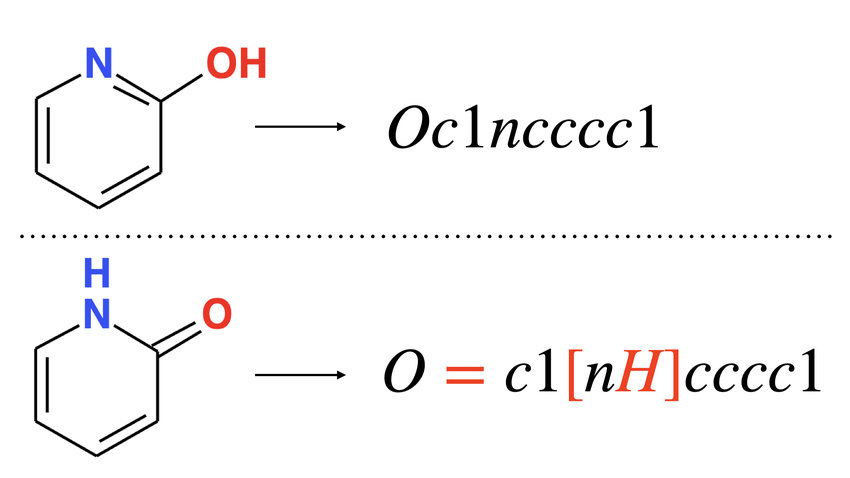

In [7]:
import pandas as pd
target = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER',
                  'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5',
                  'SR-HSE', 'SR-MMP', 'SR-p53']

for col in target:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[target].describe()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
count,5628.000000,4874.000000,4619.00000,3705.000000,4105.000000,5030.000000,4461.000000,3595.000000,5341.000000,4434.000000,3907.000000,4886.000000
mean,0.062900,0.060320,0.16562,0.089339,0.183922,0.082306,0.045505,0.257580,0.059914,0.087055,0.261582,0.108064
std,0.242804,0.238103,0.37178,0.285271,0.387468,0.274858,0.208433,0.437362,0.237349,0.281947,0.439552,0.310493
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


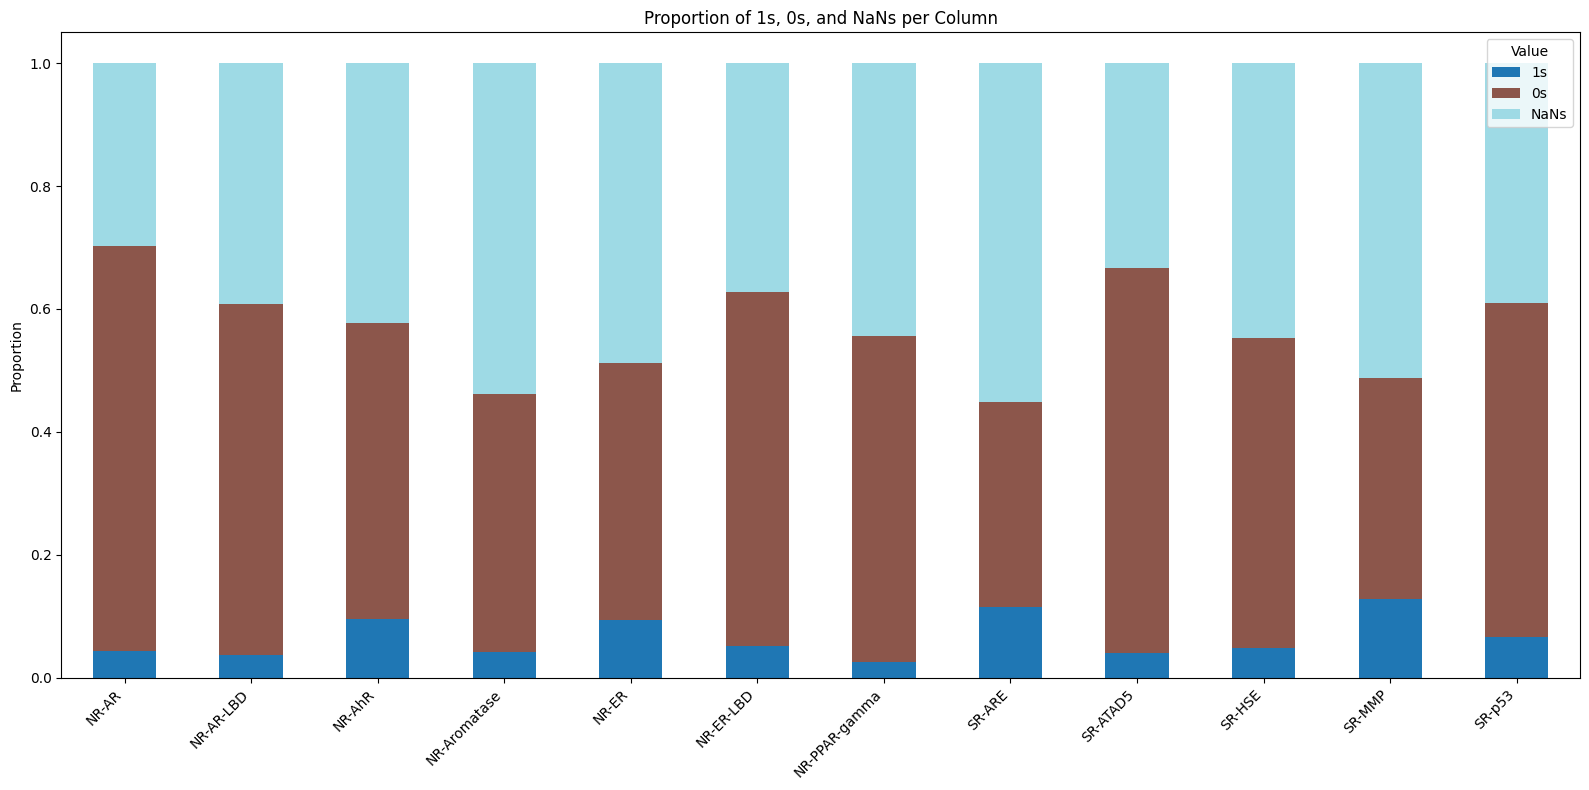

In [8]:
import matplotlib.pyplot as plt
def plot_binary_percent_stacked(df, cols):
    subset = df[cols]

    counts = pd.DataFrame({
        '1s': (subset == 1).sum(),
        '0s': (subset == 0).sum(),
        'NaNs': subset.isna().sum()
    })

    pct = counts.div(counts.sum(axis=1), axis=0)

    ax = pct.plot(
        kind='bar',
        stacked=True,
        figsize=(16, 8),
        colormap='tab20'
    )

    ax.set_ylabel('Proportion')
    ax.set_title('Proportion of 1s, 0s, and NaNs per Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.legend(title='Value')

    plt.show()

plot_binary_percent_stacked(df, target)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8013 entries, 0 to 8015
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Formula        8013 non-null   object 
 1   FW             8013 non-null   object 
 2   DSSTox_CID     8012 non-null   object 
 3   SR-HSE         4434 non-null   float64
 4   ID             8013 non-null   object 
 5   smiles         8013 non-null   object 
 6   NR-AR          5628 non-null   float64
 7   SR-ARE         3595 non-null   float64
 8   NR-Aromatase   3705 non-null   float64
 9   NR-ER-LBD      5030 non-null   float64
 10  NR-AhR         4619 non-null   float64
 11  SR-MMP         3907 non-null   float64
 12  NR-ER          4105 non-null   float64
 13  NR-PPAR-gamma  4461 non-null   float64
 14  SR-p53         4886 non-null   float64
 15  SR-ATAD5       5341 non-null   float64
 16  NR-AR-LBD      4874 non-null   float64
dtypes: float64(12), object(5)
memory usage: 1.1+ MB


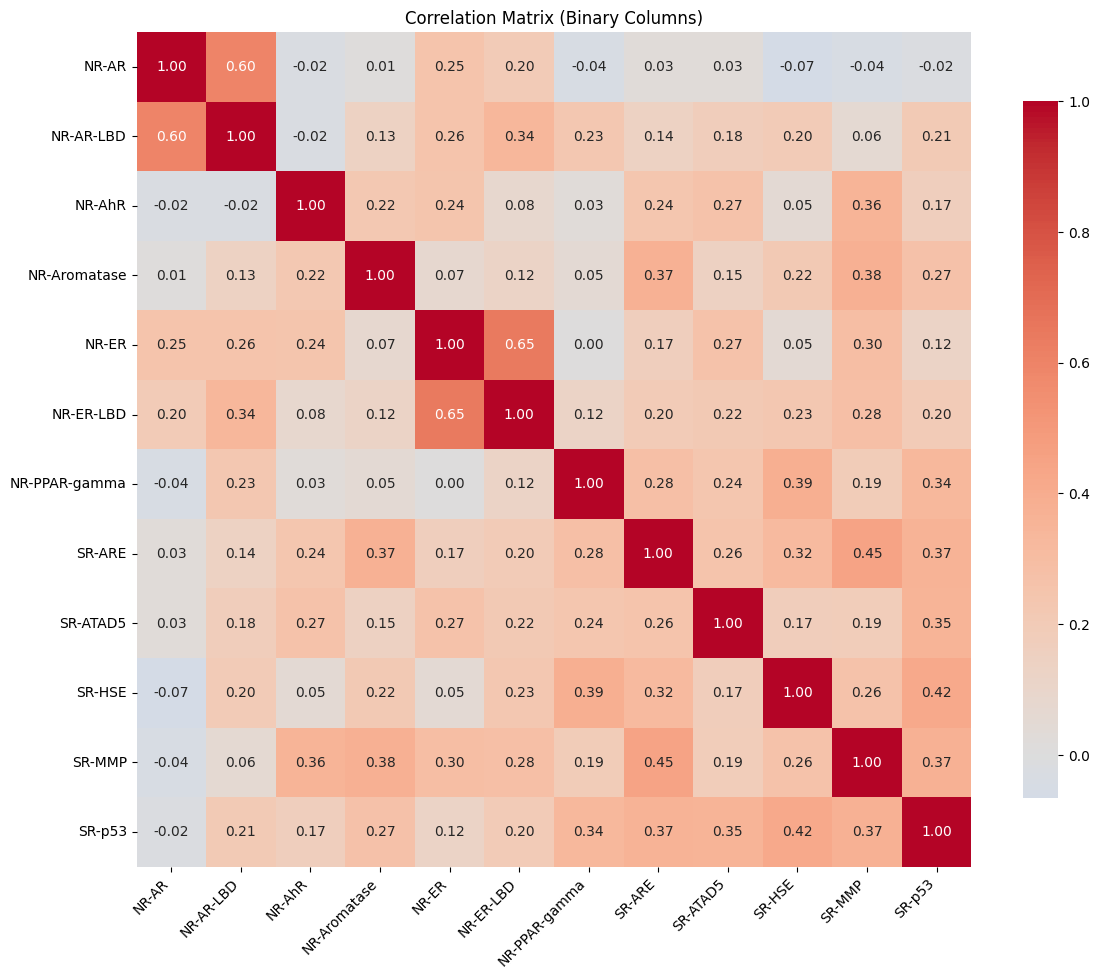

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_binary_correlation(df, cols):
    subset = df[cols]

    # Compute correlation matrix
    corr = subset.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        cbar_kws={"shrink": 0.8}
    )

    plt.title("Correlation Matrix (Binary Columns)")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# call it
plot_binary_correlation(df, target)

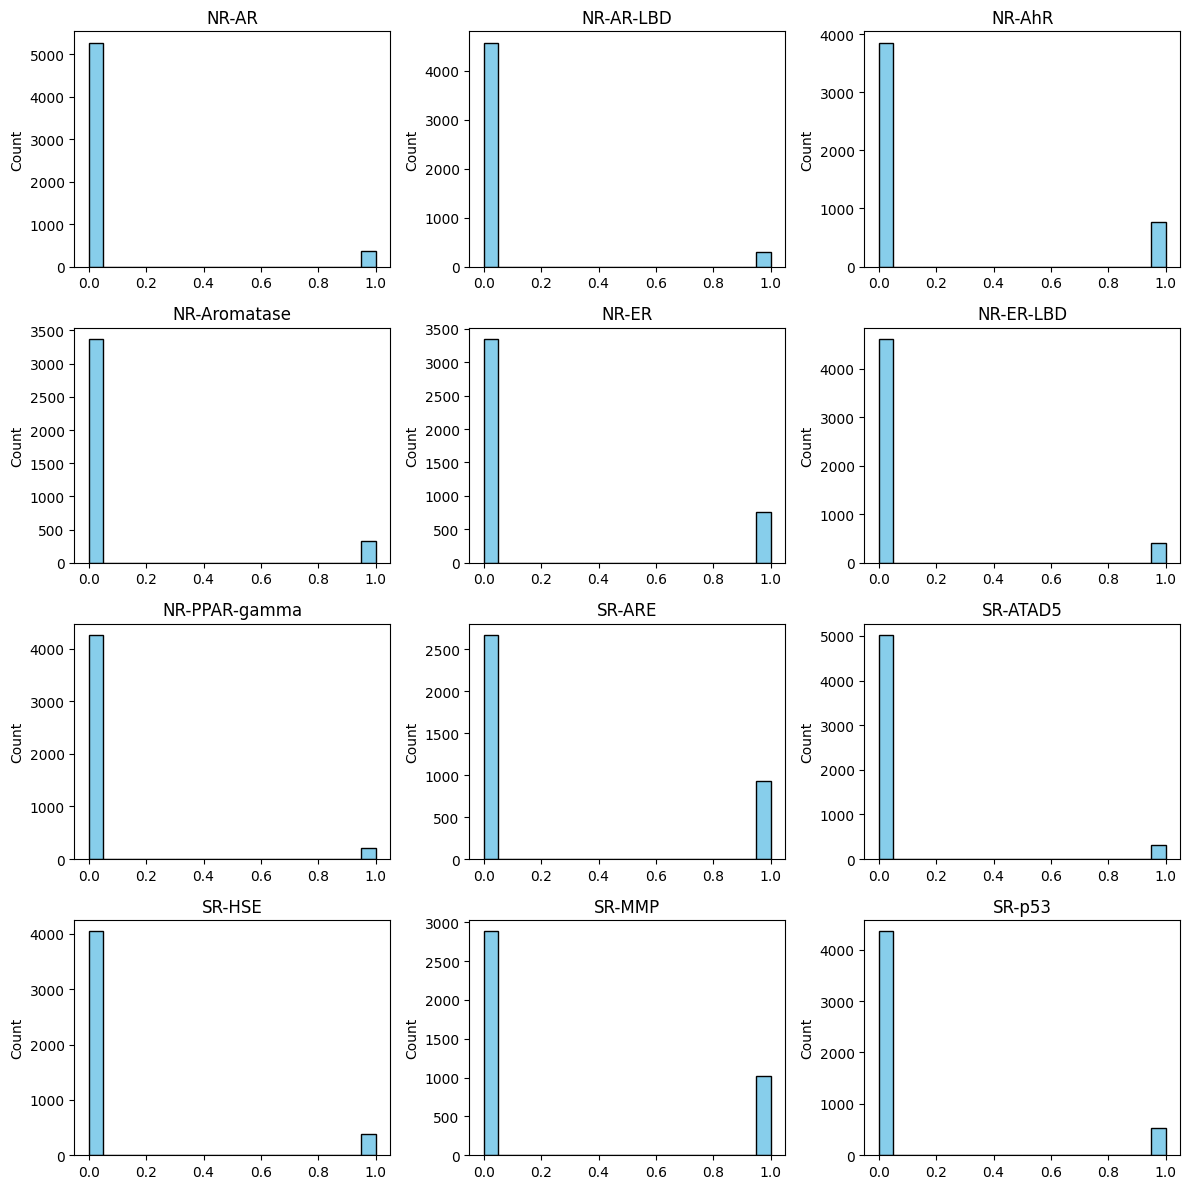

In [11]:
import math
def plot_predictor_histograms(df):
    cols = df.columns
    n_cols = len(cols)

    # Decide grid size (rows and columns) to make it roughly square
    n_rows = math.ceil(math.sqrt(n_cols))
    n_cols_grid = math.ceil(n_cols / n_rows)

    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(n_cols_grid*4, n_rows*3))
    axes = axes.flatten()  # flatten to easily iterate

    for i, col in enumerate(df.columns):
        axes[i].hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Count')

    # Turn off unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function
plot_predictor_histograms(df[target])

In [12]:
for idx, row in df.iterrows():
    if row[target].isna().all():
        print(idx)

target_NR = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER',
                  'NR-ER-LBD', 'NR-PPAR-gamma']
target_SR = ['SR-ARE', 'SR-ATAD5',
                  'SR-HSE', 'SR-MMP', 'SR-p53']



8015


In [13]:
NR_missing = []
SR_missing = []

for idx, row in df.iterrows():
    if row[target_NR].isna().all():
        NR_missing.append(idx)
    if row[target_SR].isna().all():
        SR_missing.append(idx)


In [14]:
df_NR = df[target_NR].drop(index=NR_missing)
df_SR = df[target_SR].drop(index=SR_missing)

df_NR.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN
8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
9,0.0,NaN,NaN,NaN,NaN,NaN,NaN
10,0.0,NaN,NaN,NaN,NaN,NaN,NaN
17,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df_NR.info()
df_NR.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 5814 entries, 4 to 8014
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          5628 non-null   float64
 1   NR-AR-LBD      4874 non-null   float64
 2   NR-AhR         4619 non-null   float64
 3   NR-Aromatase   3705 non-null   float64
 4   NR-ER          4105 non-null   float64
 5   NR-ER-LBD      5030 non-null   float64
 6   NR-PPAR-gamma  4461 non-null   float64
dtypes: float64(7)
memory usage: 363.4 KB


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma
count,5628.000000,4874.000000,4619.00000,3705.000000,4105.000000,5030.000000,4461.000000
mean,0.062900,0.060320,0.16562,0.089339,0.183922,0.082306,0.045505
std,0.242804,0.238103,0.37178,0.285271,0.387468,0.274858,0.208433
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [16]:

df_SR.info()
df_SR.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 7946 entries, 0 to 8014
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SR-ARE    3595 non-null   float64
 1   SR-ATAD5  5341 non-null   float64
 2   SR-HSE    4434 non-null   float64
 3   SR-MMP    3907 non-null   float64
 4   SR-p53    4886 non-null   float64
dtypes: float64(5)
memory usage: 372.5 KB


,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
count,3595.000000,5341.000000,4434.000000,3907.000000,4886.000000
mean,0.257580,0.059914,0.087055,0.261582,0.108064
std,0.437362,0.237349,0.281947,0.439552,0.310493
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
def rows_with_multiple_values(df):
    row_indices = []
    # Iterate over rows
    for idx, row in df.iterrows():
        if row.notna().sum() > 1:  # count non-NaN values
            row_indices.append(idx)
    return row_indices

# Apply to each cleaned df
nr_row_indices = rows_with_multiple_values(df_NR)
sr_row_indices = rows_with_multiple_values(df_SR)

print("Rows in df_nr_clean with >1 non-NaN value:", nr_row_indices)
print("Rows in df_sr_clean with >1 non-NaN value:", sr_row_indices)

Rows in df_nr_clean with >1 non-NaN value: [133, 474, 475, 477, 478, 479, 486, 488, 491, 492, 495, 510, 522, 523, 524, 536, 548, 576, 586, 587, 618, 650, 1589, 2243, 2244, 2245, 2247, 2248, 2249, 2250, 2252, 2253, 2255, 2256, 2257, 2258, 2259, 2261, 2262, 2263, 2264, 2265, 2267, 2269, 2270, 2271, 2273, 2274, 2275, 2277, 2279, 2280, 2281, 2282, 2283, 2284, 2285, 2286, 2287, 2288, 2289, 2290, 2292, 2293, 2294, 2295, 2297, 2298, 2299, 2301, 2302, 2303, 2305, 2306, 2307, 2308, 2309, 2310, 2313, 2314, 2316, 2317, 2318, 2319, 2320, 2321, 2322, 2323, 2324, 2325, 2326, 2327, 2328, 2329, 2330, 2331, 2332, 2333, 2334, 2335, 2336, 2337, 2338, 2339, 2340, 2341, 2342, 2343, 2344, 2345, 2346, 2347, 2348, 2349, 2350, 2352, 2353, 2354, 2356, 2357, 2358, 2359, 2360, 2361, 2362, 2363, 2365, 2366, 2367, 2368, 2369, 2370, 2371, 2372, 2373, 2374, 2375, 2376, 2377, 2378, 2379, 2380, 2381, 2382, 2383, 2384, 2386, 2387, 2388, 2389, 2390, 2393, 2394, 2395, 2396, 2397, 2398, 2399, 2400, 2401, 2402, 2403, 2404, 

In [18]:
def rows_with_different_values(df):
    differing_rows = []
    for idx, row in df.iterrows():
        # Keep only non-NaN values
        non_na_values = row.dropna().values
        if len(non_na_values) > 1:  # more than 1 non-NaN value
            if len(set(non_na_values)) > 1:  # check if any value differs
                differing_rows.append(idx)
    return differing_rows

# Apply to each cleaned df
nr_diff_rows = rows_with_different_values(df_NR)
sr_diff_rows = rows_with_different_values(df_SR)

print("Rows in df_nr_clean where non-NaN values differ:", nr_diff_rows)
print("Rows in df_sr_clean where non-NaN values differ:", sr_diff_rows)

print(df_NR.loc[[474]])

Rows in df_nr_clean where non-NaN values differ: [133, 474, 491, 522, 536, 548, 586, 587, 618, 650, 1589, 2245, 2249, 2255, 2258, 2264, 2280, 2282, 2283, 2288, 2289, 2290, 2293, 2294, 2302, 2303, 2305, 2309, 2310, 2314, 2317, 2319, 2321, 2327, 2331, 2336, 2340, 2343, 2346, 2347, 2360, 2368, 2370, 2374, 2376, 2377, 2378, 2379, 2381, 2382, 2384, 2386, 2387, 2388, 2389, 2390, 2395, 2396, 2397, 2398, 2401, 2405, 2408, 2410, 2411, 2412, 2414, 2416, 2417, 2418, 2420, 2421, 2423, 2424, 2425, 2427, 2428, 2429, 2430, 2431, 2432, 2433, 2435, 2438, 2439, 2441, 2442, 2448, 2450, 2451, 2453, 2456, 2457, 2460, 2464, 2470, 2472, 2474, 2476, 2483, 2484, 2485, 2489, 2493, 2494, 2495, 2500, 2502, 2504, 2508, 2509, 2510, 2515, 2520, 2523, 2524, 2525, 2526, 2529, 2532, 2535, 2536, 2537, 2538, 2539, 2540, 2546, 2553, 2559, 2561, 2563, 2565, 2566, 2569, 2570, 2571, 2572, 2573, 2574, 2577, 2579, 2583, 2588, 2590, 2591, 2592, 2596, 2598, 2600, 2601, 2603, 2604, 2605, 2606, 2607, 2609, 2611, 2612, 2613, 2618, 

In [19]:
import pandas as pd
from rdkit import Chem
from rdkit.ML.Descriptors.MoleculeDescriptors import MolecularDescriptorCalculator

# Your chosen descriptors
chosen_descriptors = ['MolWt', 'NHOHCount', 'NOCount',
                      'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles',
                      'NumAromaticHeterocycles', 'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms',
                      'NumRadicalElectrons', 'NumRotatableBonds', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles',
                      'NumSaturatedRings', 'NumValenceElectrons']

# Initialize descriptor calculator
calc = MolecularDescriptorCalculator(chosen_descriptors)

# Function to calculate descriptors from a SMILES
def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [None] * len(chosen_descriptors)  # handle invalid SMILES
    return list(calc.CalcDescriptors(mol))

# Apply function to DataFrame
descriptor_values = df['smiles'].apply(calc_descriptors)

# Convert list of descriptors into DataFrame
predictors = pd.DataFrame(descriptor_values.tolist(), columns=chosen_descriptors, index=df.index)

# Optional: include SMILES in final DataFrame
#predictors.insert(0, 'smiles', df['smiles'])

predictors.head()

,MolWt,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRadicalElectrons,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumValenceElectrons
0,468.992,8,6,0,0,0,4,2,6,5,4,7,0,0,0,0,0,170
1,691.859,0,5,1,1,2,2,0,2,5,0,11,0,2,0,0,0,146
2,934.171,7,18,0,7,7,0,0,0,17,4,18,0,13,0,7,7,378
3,927.020,4,16,2,0,2,4,0,4,10,4,16,0,6,0,0,0,354
4,1342.527,19,31,0,2,2,3,3,6,15,18,31,0,32,0,2,2,520


In [20]:
predictors.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8013 entries, 0 to 8015
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MolWt                     8013 non-null   float64
 1   NHOHCount                 8013 non-null   int64  
 2   NOCount                   8013 non-null   int64  
 3   NumAliphaticCarbocycles   8013 non-null   int64  
 4   NumAliphaticHeterocycles  8013 non-null   int64  
 5   NumAliphaticRings         8013 non-null   int64  
 6   NumAromaticCarbocycles    8013 non-null   int64  
 7   NumAromaticHeterocycles   8013 non-null   int64  
 8   NumAromaticRings          8013 non-null   int64  
 9   NumHAcceptors             8013 non-null   int64  
 10  NumHDonors                8013 non-null   int64  
 11  NumHeteroatoms            8013 non-null   int64  
 12  NumRadicalElectrons       8013 non-null   int64  
 13  NumRotatableBonds         8013 non-null   int64  
 14  NumSaturatedC

In [21]:
predictors.describe()

,MolWt,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRadicalElectrons,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumValenceElectrons
count,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000,8013.000000
mean,328.761209,1.846250,4.903157,0.369150,0.502059,0.871209,1.039062,0.349183,1.388244,4.065144,1.583427,6.017472,0.001622,4.688506,0.240359,0.335330,0.575690,118.777487
std,174.733740,2.590031,4.145158,0.971772,1.017276,1.421216,0.960579,0.618102,1.122611,3.414347,2.215304,4.547217,0.043238,4.564845,0.747693,0.852588,1.159591,64.538921
min,42.041000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000
25%,217.888000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,3.000000,0.000000,2.000000,0.000000,0.000000,0.000000,76.000000
50%,300.398000,1.000000,4.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.000000,1.000000,5.000000,0.000000,4.000000,0.000000,0.000000,0.000000,108.000000
75%,393.731000,2.000000,6.000000,0.000000,1.000000,1.000000,2.000000,1.000000,2.000000,5.000000,2.000000,8.000000,0.000000,6.000000,0.000000,0.000000,1.000000,144.000000
max,1950.681000,40.000000,67.000000,6.000000,22.000000,22.000000,10.000000,5.000000,12.000000,67.000000,36.000000,91.000000,2.000000,47.000000,6.000000,22.000000,22.000000,704.000000


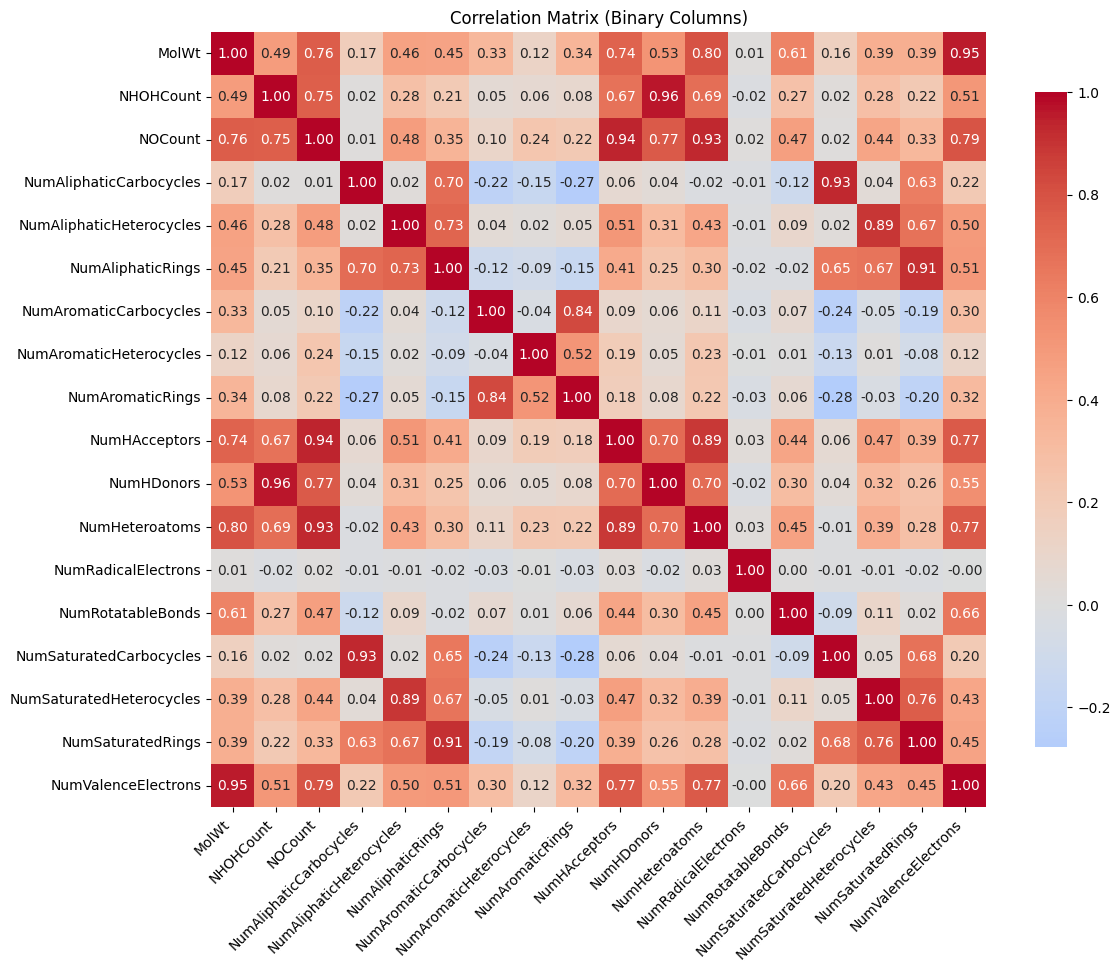

In [22]:
corr = predictors.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Binary Columns)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

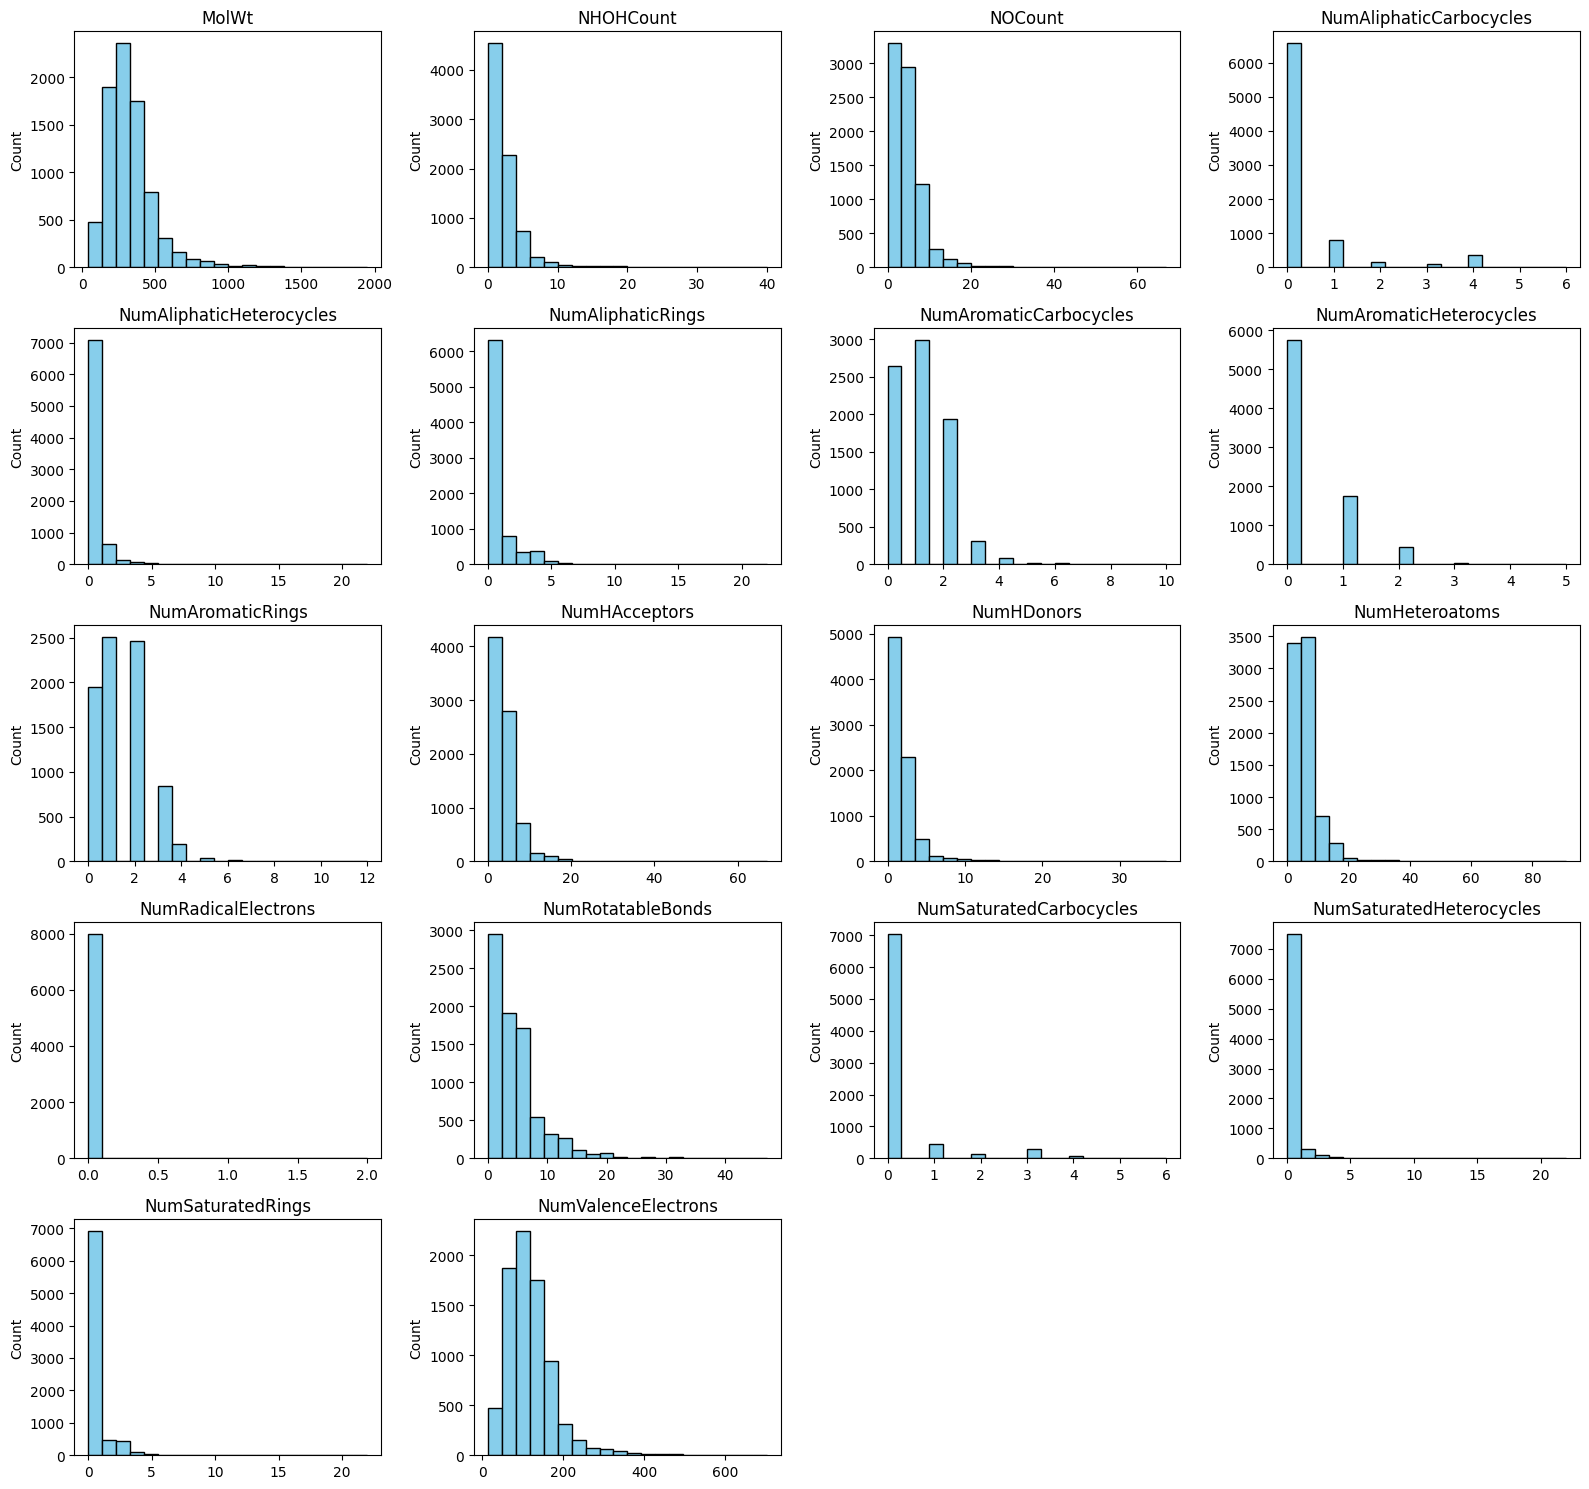

In [23]:
import math
def plot_predictor_histograms(df):
    cols = df.columns
    n_cols = len(cols)

    # Decide grid size (rows and columns) to make it roughly square
    n_rows = math.ceil(math.sqrt(n_cols))
    n_cols_grid = math.ceil(n_cols / n_rows)

    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(n_cols_grid*4, n_rows*3))
    axes = axes.flatten()  # flatten to easily iterate

    for i, col in enumerate(df.columns):
        axes[i].hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Count')

    # Turn off unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function
plot_predictor_histograms(predictors)

In [24]:
predictors_NR = predictors.drop(index=NR_missing)
predictors_SR = predictors.drop(index=SR_missing)
predictors.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8013 entries, 0 to 8015
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MolWt                     8013 non-null   float64
 1   NHOHCount                 8013 non-null   int64  
 2   NOCount                   8013 non-null   int64  
 3   NumAliphaticCarbocycles   8013 non-null   int64  
 4   NumAliphaticHeterocycles  8013 non-null   int64  
 5   NumAliphaticRings         8013 non-null   int64  
 6   NumAromaticCarbocycles    8013 non-null   int64  
 7   NumAromaticHeterocycles   8013 non-null   int64  
 8   NumAromaticRings          8013 non-null   int64  
 9   NumHAcceptors             8013 non-null   int64  
 10  NumHDonors                8013 non-null   int64  
 11  NumHeteroatoms            8013 non-null   int64  
 12  NumRadicalElectrons       8013 non-null   int64  
 13  NumRotatableBonds         8013 non-null   int64  
 14  NumSaturatedC

In [25]:
# For those same examples above, what do they look like after being pre-processed?
df.tail()
df.info()
df.head()


predictors.tail()

<class 'pandas.core.frame.DataFrame'>
Index: 8013 entries, 0 to 8015
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Formula        8013 non-null   object 
 1   FW             8013 non-null   object 
 2   DSSTox_CID     8012 non-null   object 
 3   SR-HSE         4434 non-null   float64
 4   ID             8013 non-null   object 
 5   smiles         8013 non-null   object 
 6   NR-AR          5628 non-null   float64
 7   SR-ARE         3595 non-null   float64
 8   NR-Aromatase   3705 non-null   float64
 9   NR-ER-LBD      5030 non-null   float64
 10  NR-AhR         4619 non-null   float64
 11  SR-MMP         3907 non-null   float64
 12  NR-ER          4105 non-null   float64
 13  NR-PPAR-gamma  4461 non-null   float64
 14  SR-p53         4886 non-null   float64
 15  SR-ATAD5       5341 non-null   float64
 16  NR-AR-LBD      4874 non-null   float64
dtypes: float64(12), object(5)
memory usage: 1.4+ MB


,MolWt,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRadicalElectrons,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumValenceElectrons
8011,132.232,2,2,0,0,0,0,0,0,1,2,3,0,2,0,0,0,48
8012,295.338,0,4,0,1,1,2,0,2,4,0,4,0,4,0,0,0,112
8013,166.176,1,3,0,0,0,1,0,1,3,1,3,0,3,0,0,0,64
8014,376.496,0,3,0,0,0,3,0,3,3,0,3,0,9,0,0,0,146
8015,179.219,1,3,0,0,0,1,0,1,2,1,3,0,3,0,0,0,70


In [26]:
print(df.index.equals(predictors.index))  # should be True
print(df.index[:10])
print(predictors.index[:10])

print(set(df.index) - set(predictors.index))



df.info()


True
Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')
Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')
set()
<class 'pandas.core.frame.DataFrame'>
Index: 8013 entries, 0 to 8015
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Formula        8013 non-null   object 
 1   FW             8013 non-null   object 
 2   DSSTox_CID     8012 non-null   object 
 3   SR-HSE         4434 non-null   float64
 4   ID             8013 non-null   object 
 5   smiles         8013 non-null   object 
 6   NR-AR          5628 non-null   float64
 7   SR-ARE         3595 non-null   float64
 8   NR-Aromatase   3705 non-null   float64
 9   NR-ER-LBD      5030 non-null   float64
 10  NR-AhR         4619 non-null   float64
 11  SR-MMP         3907 non-null   float64
 12  NR-ER          4105 non-null   float64
 13  NR-PPAR-gamma  4461 non-null   float64
 14  SR-p53         4886 non-null   float64
 15  SR-ATAD5       5341 non-null

In [27]:
predictors.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8013 entries, 0 to 8015
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MolWt                     8013 non-null   float64
 1   NHOHCount                 8013 non-null   int64  
 2   NOCount                   8013 non-null   int64  
 3   NumAliphaticCarbocycles   8013 non-null   int64  
 4   NumAliphaticHeterocycles  8013 non-null   int64  
 5   NumAliphaticRings         8013 non-null   int64  
 6   NumAromaticCarbocycles    8013 non-null   int64  
 7   NumAromaticHeterocycles   8013 non-null   int64  
 8   NumAromaticRings          8013 non-null   int64  
 9   NumHAcceptors             8013 non-null   int64  
 10  NumHDonors                8013 non-null   int64  
 11  NumHeteroatoms            8013 non-null   int64  
 12  NumRadicalElectrons       8013 non-null   int64  
 13  NumRotatableBonds         8013 non-null   int64  
 14  NumSaturatedC

In [31]:
target = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER',
                  'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5',
                  'SR-HSE', 'SR-MMP', 'SR-p53']



y_NR_AR = df[['NR-AR']].dropna()
X_NR_AR = predictors.loc[y_NR_AR.index]

y_NR_AR_LBD = df[['NR-AR-LBD']].dropna()
X_NR_AR_LBD = predictors.loc[y_NR_AR_LBD.index]

y_NR_AhR = df[['NR-AhR']].dropna()
X_NR_AhR = predictors.loc[y_NR_AhR.index]

y_NR_Aromatase = df[['NR-Aromatase']].dropna()
X_NR_Aromatase = predictors.loc[y_NR_Aromatase.index]

y_NR_ER = df[['NR-ER']].dropna()
X_NR_ER = predictors.loc[y_NR_ER.index]

y_NR_ER_LBD = df[['NR-ER-LBD']].dropna()
X_NR_ER_LBD = predictors.loc[y_NR_ER_LBD.index]

y_NR_PPAR_gamma = df[['NR-PPAR-gamma']].dropna()
X_NR_PPAR_gamma = predictors.loc[y_NR_PPAR_gamma.index]

y_SR_ARE = df[['SR-ARE']].dropna()
X_SR_ARE = predictors.loc[y_SR_ARE.index]

y_SR_ATAD5 = df[['SR-ATAD5']].dropna()
X_SR_ATAD5 = predictors.loc[y_SR_ATAD5.index]

y_SR_HSE = df[['SR-HSE']].dropna()
X_SR_HSE = predictors.loc[y_SR_HSE.index]

y_SR_MMP = df[['SR-MMP']].dropna()
X_SR_MMP = predictors.loc[y_SR_MMP.index]

y_SR_p53 = df[['SR-p53']].dropna()
X_SR_p53 = predictors.loc[y_SR_p53.index]

In [32]:
y_NR_AR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5628 entries, 4 to 8014
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NR-AR   5628 non-null   float64
dtypes: float64(1)
memory usage: 87.9 KB


In [33]:
X_NR_AR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5628 entries, 4 to 8014
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MolWt                     5628 non-null   float64
 1   NHOHCount                 5628 non-null   int64  
 2   NOCount                   5628 non-null   int64  
 3   NumAliphaticCarbocycles   5628 non-null   int64  
 4   NumAliphaticHeterocycles  5628 non-null   int64  
 5   NumAliphaticRings         5628 non-null   int64  
 6   NumAromaticCarbocycles    5628 non-null   int64  
 7   NumAromaticHeterocycles   5628 non-null   int64  
 8   NumAromaticRings          5628 non-null   int64  
 9   NumHAcceptors             5628 non-null   int64  
 10  NumHDonors                5628 non-null   int64  
 11  NumHeteroatoms            5628 non-null   int64  
 12  NumRadicalElectrons       5628 non-null   int64  
 13  NumRotatableBonds         5628 non-null   int64  
 14  NumSaturatedC

# Models and Evaluation

## Experimental Setup

**How did you evaluate your methods? Why is that a reasonable evaluation metric for the task?**
**What did you use for your loss function to train your models? Did you try multiple loss functions? Why or why not?**
**How did you split your data into train and test sets? Why?**


We evaluated using accuracy, precision, recall, F1, and ROC-AUC across all 12 assays. ROC-AUC is the primary metric because it is threshold-independent and measures the model's ability to rank toxic compounds above non-toxic ones across all possible decision boundaries — directly relevant to a screening task. For imbalanced toxicity datasets (some assays have as few as 2.7% positives), accuracy is misleading since predicting all-negative gives 97% accuracy while being completely useless. Recall is prioritized in threshold selection because in toxicity screening, a false negative (missing a toxic compound) is far more costly than a false positive. F1 balances recall against precision to prevent the degenerate all-positive prediction strategy. The threshold sweep (0.10–0.50) lets us explicitly control this tradeoff rather than accepting sklearn's default 0.5 cutoff.

Random Forest does not use a loss function in the gradient-descent sense. Each tree is built by greedily maximizing Gini impurity reduction at each split — it selects the feature and threshold that most cleanly separates classes in each node. We did not try alternative criteria (e.g. entropy/log-loss) because Gini and entropy perform nearly identically in practice on tabular data, and the more impactful lever was the choice of evaluation metric for hyperparameter selection. We used ROC-AUC as the refit scoring metric in RandomizedSearchCV rather than F1 or Gini directly, because ROC-AUC is threshold-independent and doesn't collapse to zero on heavily imbalanced folds the way F1 does.

Neural network uses BCEWithLogitsLoss with pos_weight = n_neg/n_pos, which combines sigmoid activation and binary cross-entropy into a single numerically stable operation. The pos_weight term scales the loss contribution of positive (toxic) examples by the class imbalance ratio, directly compensating for the minority class without resampling. We did not try alternative loss functions such as focal loss, though it would be a natural next step given the severe imbalance in several assays.

Each of the 12 datasets was split 80/20 (train/test) using train_test_split with stratify=y and random_state=42. Stratification preserves the positive class ratio in both sets, which matters when some assays have only 2–5% positives — without it, a random split could put almost all positives in one set. The 80/20 ratio is standard for datasets of this size (7,000–9,000 samples). The hold-out test set was never touched during hyperparameter tuning; all tuning decisions were made on the training set via cross-validation.

## Baselines

The default Random Forest with threshold of 0.5 was the baseline. This model was simple to train, and gave us a sense of unoptimized performance and what our goals for improvment should be. From there, we optimized the RF and NN models and find the best threshold values, and saw how performance changes.

The original Tox21 Data Challenge (2014) winner, DeepTox, achieved ROC-AUC scores ranging from 0.79–0.94 across assays using a deep multi-task neural network trained on thousands of additional features and external compound databases. Our models operate under more constrained conditions, trained only on the Tox21 training set with 2066 features, making the published challenge results an upper-bound reference rather than a direct comparison.

Mayr A, Klambauer G, Unterthiner T and Hochreiter S (2016) DeepTox: Toxicity Prediction using Deep Learning. Front. Environ. Sci. 3:80. doi: 10.3389/fenvs.2015.00080

### Default Random Forest

In [32]:
from rdkit.Chem import rdFingerprintGenerator

# Integrate morgan fingerprints into hand-picked features
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def get_morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [0] * 2048
    return list(morgan_gen.GetFingerprintAsNumPy(mol))

morgan_fps = pd.DataFrame(
    df['smiles'].apply(get_morgan_fp).tolist(),
    index=df.index
)
predictors_full = pd.concat([predictors, morgan_fps], axis=1)
predictors_full.columns = predictors_full.columns.astype(str)
predictors_full.info()

# Make dataset for each of 12 assays
y_NR_AR = df[['NR-AR']].dropna()
X_NR_AR = predictors_full.loc[y_NR_AR.index]

y_NR_AR_LBD = df[['NR-AR-LBD']].dropna()
X_NR_AR_LBD = predictors_full.loc[y_NR_AR_LBD.index]

y_NR_AhR = df[['NR-AhR']].dropna()
X_NR_AhR = predictors_full.loc[y_NR_AhR.index]

y_NR_Aromatase = df[['NR-Aromatase']].dropna()
X_NR_Aromatase = predictors_full.loc[y_NR_Aromatase.index]

y_NR_ER = df[['NR-ER']].dropna()
X_NR_ER = predictors_full.loc[y_NR_ER.index]

y_NR_ER_LBD = df[['NR-ER-LBD']].dropna()
X_NR_ER_LBD = predictors_full.loc[y_NR_ER_LBD.index]

y_NR_PPAR_gamma = df[['NR-PPAR-gamma']].dropna()
X_NR_PPAR_gamma = predictors_full.loc[y_NR_PPAR_gamma.index]

y_SR_ARE = df[['SR-ARE']].dropna()
X_SR_ARE = predictors_full.loc[y_SR_ARE.index]

y_SR_ATAD5 = df[['SR-ATAD5']].dropna()
X_SR_ATAD5 = predictors_full.loc[y_SR_ATAD5.index]

y_SR_HSE = df[['SR-HSE']].dropna()
X_SR_HSE = predictors_full.loc[y_SR_HSE.index]

y_SR_MMP = df[['SR-MMP']].dropna()
X_SR_MMP = predictors_full.loc[y_SR_MMP.index]

y_SR_p53 = df[['SR-p53']].dropna()
X_SR_p53 = predictors_full.loc[y_SR_p53.index]

[23:46:36] WARNING: not removing hydrogen atom without neighbors


<class 'pandas.core.frame.DataFrame'>
Index: 11761 entries, 0 to 11763
Columns: 2066 entries, MolWt to 2047
dtypes: float64(1), int64(17), uint8(2048)
memory usage: 24.9 MB



  Dataset: NR-AR  (n=9360)
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      1787
         1.0       0.94      0.55      0.70        85

    accuracy                           0.98      1872
   macro avg       0.96      0.78      0.84      1872
weighted avg       0.98      0.98      0.98      1872


  Dataset: NR-AR-LBD  (n=8597)
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      1657
         1.0       0.88      0.73      0.80        63

    accuracy                           0.99      1720
   macro avg       0.94      0.86      0.90      1720
weighted avg       0.99      0.99      0.99      1720


  Dataset: NR-AhR  (n=8167)
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97      1446
         1.0       0.88      0.53      0.66       188

    accuracy                           0.94      1634
   macro avg       0.91      0.76      

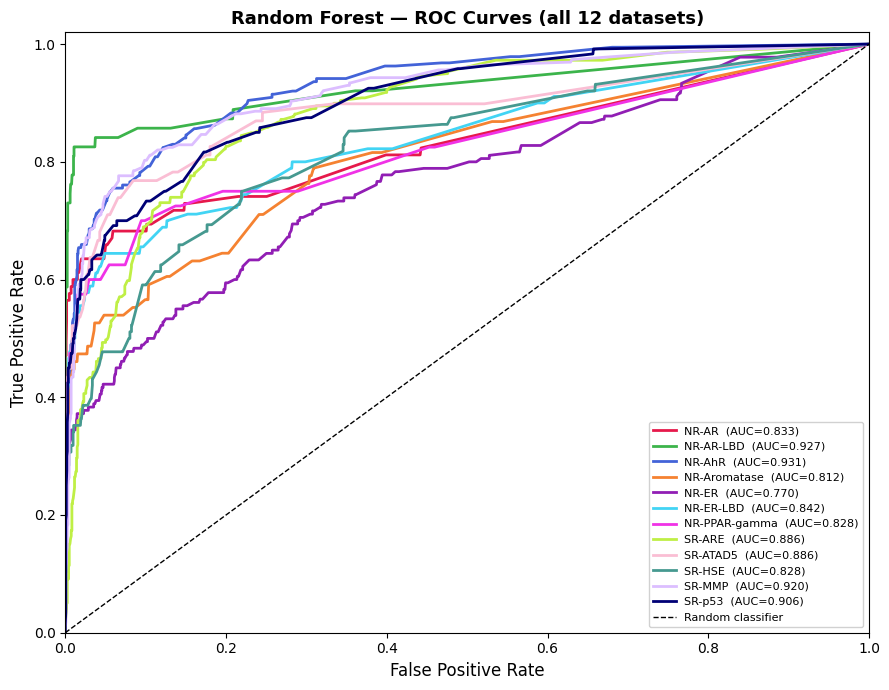

Saved: rf_roc_curves.png


In [ ]:
# Code for loss functions, evaluation metrics or link to Git repo
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
)

datasets = {
    "NR-AR":         (X_NR_AR,         y_NR_AR),
    "NR-AR-LBD":     (X_NR_AR_LBD,     y_NR_AR_LBD),
    "NR-AhR":        (X_NR_AhR,        y_NR_AhR),
    "NR-Aromatase":  (X_NR_Aromatase,  y_NR_Aromatase),
    "NR-ER":         (X_NR_ER,         y_NR_ER),
    "NR-ER-LBD":     (X_NR_ER_LBD,     y_NR_ER_LBD),
    "NR-PPAR-gamma": (X_NR_PPAR_gamma, y_NR_PPAR_gamma),
    "SR-ARE":        (X_SR_ARE,        y_SR_ARE),
    "SR-ATAD5":      (X_SR_ATAD5,      y_SR_ATAD5),
    "SR-HSE":        (X_SR_HSE,        y_SR_HSE),
    "SR-MMP":        (X_SR_MMP,        y_SR_MMP),
    "SR-p53":        (X_SR_p53,        y_SR_p53),
}

results  = {}
roc_data = {}

for name, (X, y) in datasets.items():
    print(f"\n{'='*50}")
    print(f"  Dataset: {name}  (n={len(y)})")
    print(f"{'='*50}")

    y_flat = y.values.ravel().astype(np.float32) #flatten to 1D

    X_train, X_test, y_train, y_test = train_test_split(X, y_flat, test_size=0.2, random_state=42)

    clf = RandomForestClassifier(random_state=42)  # default threshold = 0.5
    clf.fit(X_train, y_train)

    y_pred  = clf.predict(X_test)        # uses 0.5 threshold
    y_probs = clf.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy":  round(accuracy_score(y_test, y_pred),                    4),
        "Recall":    round(recall_score(y_test, y_pred,    zero_division=0),  4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0),  4),
        "F1":        round(f1_score(y_test, y_pred,        zero_division=0),  4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_probs),                    4),
    }

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_data[name] = (fpr, tpr, results[name]["ROC-AUC"])

    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results).T
print("\n" + "="*55)
print("  RANDOM FOREST SUMMARY — ALL DATASETS")
print("="*55)
print(results_df.to_string())
results_df.to_csv("rf_metrics_summary.csv")
print("\nSaved → rf_metrics_summary.csv")

colors = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990",
    "#dcbeff", "#000075"
]

fig, ax = plt.subplots(figsize=(9, 7))

for (name, (fpr, tpr, auc_val)), color in zip(roc_data.items(), colors):
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Random Forest — ROC Curves (all 12 datasets)", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="lower right", framealpha=0.9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("rf_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_roc_curves.png")

## Methods

**What methods did you choose? Why did you choose them?**
**How did you train these methods, and how did you evaluate them? Why?**
**Which methods were easy/difficult to implement and train? Why?**
**For each method, what hyperparameters did you evaluate? How sensitive was your model's performance to different hyperparameter settings?**

For Random Forest:

We chose Random Forest as one method (compared against a neural network). Random Forest was chosen because: (1) it handles mixed feature types and scales well to the ~2,000+ features from Morgan fingerprints plus hand-crafted descriptors without requiring normalization; (2) it is naturally resistant to irrelevant features through random feature subsampling at each split, important when 2,048 of the features are binary Morgan fingerprint bits of varying relevance; (3) it provides feature importance estimates natively, enabling SHAP analysis; and (4) it is a well-validated baseline for molecular property prediction and toxicity tasks in cheminformatics literature.

Training used RandomizedSearchCV with 5-fold stratified cross-validation on the training set, sampling 30 random combinations from the hyperparameter grid, with ROC-AUC as the refit criterion. After selecting the best parameters, the model was refit on the full training set and evaluated on the hold-out test set. We then swept decision thresholds (0.10–0.50) on the test set probabilities to find the optimal operating point prioritizing recall ≥ 0.50. 5-fold CV was chosen over a single validation split to get a more stable estimate of generalization performance with lower variance, and to ensure every training sample contributes to validation at some point. Randomized search over 30 combinations was used instead of exhaustive grid search because the parameter space (5 hyperparameters × multiple values) would require hundreds of fits per dataset × 12 datasets, making full grid search computationally prohibitive.

Random Forest was relatively straightforward to implement via sklearn — the main complexity was the feature pipeline (Morgan fingerprint generation via RDKit + hand-crafted descriptors, column name type conflict resolution) and the threshold analysis layer on top of the standard fit/predict workflow. The main difficulty was managing class imbalance: the default 0.5 threshold caused F1 and Recall to collapse to zero in cross-validation for several severely imbalanced assays (NR-PPAR-gamma at 2.7% positive, SR-ATAD5 at 3.7%, SR-HSE at 5.3%), requiring the threshold sweep and the shift to ROC-AUC as the primary CV metric. Hyperparameter tuning required several iterations to balance regularization against underfitting — early runs with unconstrained max_depth and min_samples_leaf=1 showed large train-val AUC gaps, requiring progressively tighter bounds.

For Random Forest we tuned: n_estimators [100, 200, 300, 500], max_depth [5, 10, 15], min_samples_leaf [4, 8, 16], min_samples_split [5, 10, 20], max_features ["sqrt", "log2"], and max_samples [0.6, 0.7, 0.8, 1.0]. The most impactful parameters were max_depth and min_samples_leaf — early experiments with max_depth=None and min_samples_leaf=1 produced train AUCs of 0.98–0.99 with val AUCs 0.10–0.20 lower, indicating memorization. Constraining max_depth ≤ 15 and min_samples_leaf ≥ 4 brought the train-val gap under 0.15 for all datasets. max_features had moderate impact; n_estimators showed diminishing returns above 200 for most datasets. max_samples helped most for the smaller positive-class datasets. The most consistently selected combination across datasets was max_depth=15, min_samples_leaf=4, max_samples=0.8, max_features="sqrt".

For Neural Network:

We chose a feedforward neural network as the second model. Neural networks were selected for their ability to learn complex nonlinear feature interactions, particularly combinations of Morgan fingerprint bits that no single descriptor can capture. The network consists of two hidden layers (512 → 256 neurons) with ReLU activations and dropout (p=0.3) after each hidden layer to reduce overfitting. The output is a single logit passed through sigmoid to produce a toxicity probability. We used BCEWithLogitsLoss with pos_weight = n_neg/n_pos to upweight the minority toxic class, addressing class imbalance directly in the loss function. The model was trained with Adam (lr=0.001) for 200 epochs. Only the 18 continuous descriptors were standardized with StandardScaler fit on the training set — the 2048 binary Morgan fingerprint bits were left unscaled, since standardizing binary features distorts their sparse structure.

The most impactful hyperparameter was the learning rate. With a high learning rate like 0.1, training loss could drop to nearly zero within 50 epochs, and when performing cross-validation the validation loss was much higher. Setting a fixed epochs of 200 and lr=0.001 led helped reduce overfitting. There were diminishing returns when using more nodes than 512 → 256 for the hidden layers. The held out test set from the 80/20 split was not used during training.

The main challenges for the NN were overfitting and the class imbalance. Using pos_weight in the loss function was one way to address this to prevent over-picking of negative to improve accuracy.

### Optimized Random Forest

In [ ]:
!pip install shap imbalanced-learn

In [ ]:
#  WORKFLOW:
#  1. RandomizedSearchCV finds best hyperparameters using 5-fold
#     CV on the training set (80%), scored on F1 + Recall.
#  2. Best model is refit on the full training set.
#  3. Threshold sweep (0.2–0.5) is applied to predict_proba
#     on the hold-out test set (20%) — never seen during tuning.
#  4. Overfitting check: train vs. validation F1 gap reported
#     for each dataset's best parameter combination.
#  5. SHAP run on the best model to explain feature importance.
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve, make_scorer,
)
import shap

# ── Dataset registry ──────────────────────────────────────────────────────────
datasets = {
    "NR-AR":         (X_NR_AR,         y_NR_AR),
    "NR-AR-LBD":     (X_NR_AR_LBD,     y_NR_AR_LBD),
    "NR-AhR":        (X_NR_AhR,        y_NR_AhR),
    "NR-Aromatase":  (X_NR_Aromatase,  y_NR_Aromatase),
    "NR-ER":         (X_NR_ER,         y_NR_ER),
    "NR-ER-LBD":     (X_NR_ER_LBD,     y_NR_ER_LBD),
    "NR-PPAR-gamma": (X_NR_PPAR_gamma, y_NR_PPAR_gamma),
    "SR-ARE":        (X_SR_ARE,        y_SR_ARE),
    "SR-ATAD5":      (X_SR_ATAD5,      y_SR_ATAD5),
    "SR-HSE":        (X_SR_HSE,        y_SR_HSE),
    "SR-MMP":        (X_SR_MMP,        y_SR_MMP),
    "SR-p53":        (X_SR_p53,        y_SR_p53),
}

# ── Hyperparameter search space ───────────────────────────────────────────────
param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [5, 10, 15],
    "min_samples_leaf":  [4, 8, 16],
    "max_features":      ["sqrt", "log2"],
    "min_samples_split": [5, 10, 20],
    "max_samples":       [0.6, 0.7, 0.8, 1.0],
}

# ── Custom ROC-AUC scorer that handles single-class folds gracefully ──────────
scoring = {
    "F1":        make_scorer(f1_score,        zero_division=0),
    "Recall":    make_scorer(recall_score,     zero_division=0),
    "Accuracy":  make_scorer(accuracy_score),
    "Precision": make_scorer(precision_score,  zero_division=0),
    "ROC-AUC":   "roc_auc",   # built-in string scorer; bad folds return NaN via error_score
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Thresholds to test on the hold-out set after tuning
THRESHOLDS = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

# ── Storage ───────────────────────────────────────────────────────────────────
cv_results       = {}
tuned_results    = {}   # metrics per threshold on hold-out test set
best_params_all  = {}
overfit_check    = {}   # train vs val F1 gap
roc_data         = {}
optimal_thresh   = {}

def metrics_at_threshold(y_true, y_probs, threshold):
    """All threshold-dependent metrics (ROC-AUC reported separately).
    When no positives are predicted, precision is flagged as N/A rather than
    showing 0 (which looks like wrong predictions but means no predictions made).
    """
    y_pred = (y_probs >= threshold).astype(int)
    n_pred_pos = y_pred.sum()
    return {
        "Accuracy":  round(accuracy_score(y_true, y_pred),                   4),
        "Recall":    round(recall_score(y_true, y_pred,   zero_division=0),  4),
        "Precision": round(precision_score(y_true, y_pred,zero_division=0),  4)
                     if n_pred_pos > 0 else "N/A (no pos pred)",
        "F1":        round(f1_score(y_true, y_pred,       zero_division=0),  4),
        "_n_pred_pos": int(n_pred_pos),   # hidden field for best-F1 selection
    }

for name, (X, y) in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name}  (n={len(y)}, positives={int(y.values.sum())})")
    print(f"{'='*60}")

    y_flat = y.values.ravel()

    # 80% train / 20% hold-out — test set never used during tuning
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_flat, test_size=0.2, stratify=y_flat, random_state=42
    )

    # ── Step 1: RandomizedSearchCV on training set only ───────────────────────
    search = RandomizedSearchCV(
        RandomForestClassifier(random_state=42),
        param_distributions=param_dist,
        n_iter=30,
        scoring=scoring,
        refit="ROC-AUC",  # threshold-independent; avoids F1 collapse on imbalanced data
        cv=cv5,
        n_jobs=-1,
        random_state=42,
        verbose=0,
        return_train_score=True, # needed for overfitting check
        error_score=np.nan,      # don't crash on bad folds
    )
    search.fit(X_train, y_train)

    best_params_all[name] = search.best_params_
    print(f"  Best params: {search.best_params_}")

    # ── Overfitting check: train F1 vs validation F1 at best params ───────────
    cv_res    = search.cv_results_
    best_idx  = search.best_index_
    train_auc = cv_res["mean_train_ROC-AUC"][best_idx]
    val_auc   = cv_res["mean_test_ROC-AUC"][best_idx]
    gap       = train_auc - val_auc
    overfit_flag = "possible overfit" if gap > 0.15 else "OK"
    overfit_check[name] = {
        "Train AUC": round(train_auc, 4),
        "Val AUC":   round(val_auc,   4),
        "Gap":       round(gap,       4),
        "Status":    overfit_flag,
    }
    print(f"  Overfit check — Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f} | Gap: {gap:.4f} {overfit_flag}")

    # ── CV scores at best params: use nanmean/nanstd so one bad fold ─────────
    # doesn't poison the whole average (common for ROC-AUC on rare endpoints)
    cv_results[name] = {}
    n_splits = cv5.n_splits
    for metric in scoring:
        split_scores = np.array([
            cv_res[f"split{i}_test_{metric}"][best_idx] for i in range(n_splits)
        ], dtype=float)
        mean_val = np.nanmean(split_scores)
        std_val  = np.nanstd(split_scores)
        n_valid  = int(np.sum(~np.isnan(split_scores)))
        if n_valid == 0:
            cv_results[name][metric] = "NaN (all folds single-class)"
        elif n_valid < n_splits:
            cv_results[name][metric] = f"{mean_val:.4f} ± {std_val:.4f}  (over {n_valid}/{n_splits} valid folds)"
        else:
            cv_results[name][metric] = f"{mean_val:.4f} ± {std_val:.4f}"

    print(f"  5-fold CV scores:")
    for metric, val in cv_results[name].items():
        print(f"    {metric:10s}: {val}")

    # ── Step 2: Evaluate best model on hold-out test set ──────────────────────
    best_clf = search.best_estimator_    # already refit on full X_train
    y_probs  = best_clf.predict_proba(X_test)[:, 1]

    # ROC-AUC is threshold-independent — report once
    roc_auc_val = roc_auc_score(y_test, y_probs)
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_data[name] = (fpr, tpr, roc_auc_val)

    # ── Step 3: Threshold sweep on hold-out test set ──────────────────────────
    # Collect all threshold metrics first, then find best, then print
    thresh_metrics = {}
    for t in THRESHOLDS:
        thresh_metrics[t] = metrics_at_threshold(y_test, y_probs, t)

    # Find single best threshold by F1 (ties broken by lower threshold = higher recall)
    # Best threshold: among those with recall >= 0.50, pick highest F1.
    # If none reach the recall floor, fall back to highest-recall threshold.
    RECALL_FLOOR = 0.50
    candidates = {t: m for t, m in thresh_metrics.items() if m["Recall"] >= RECALL_FLOOR}
    if candidates:
        best_t = max(candidates, key=lambda t: candidates[t]["F1"])
    else:
        best_t = max(thresh_metrics, key=lambda t: thresh_metrics[t]["Recall"])

    print(f"\n  Hold-out test metrics by threshold (ROC-AUC={roc_auc_val:.4f}, threshold-independent):")
    print(f"  {'Threshold':>10} {'Accuracy':>10} {'Recall':>10} {'Precision':>10} {'F1':>10}")
    for t in THRESHOLDS:
        m      = thresh_metrics[t]
        marker = " ◄ selected (recall>=0.5, max F1)" if t == best_t else ""
        prec_str = f"{m['Precision']:>10}" if isinstance(m['Precision'], float) else f"{'N/A':>10}"
        note_str = "  (no pos predicted)" if m['_n_pred_pos'] == 0 else ""
        print(f"  {t:>10.2f} {m['Accuracy']:>10} {m['Recall']:>10} {prec_str} {m['F1']:>10}{marker}{note_str}")

    tuned_results[name] = thresh_metrics
    optimal_thresh[name] = best_t

# ── Save CSVs ─────────────────────────────────────────────────────────────────
cv_df       = pd.DataFrame(cv_results).T
params_df   = pd.DataFrame(best_params_all).T
overfit_df  = pd.DataFrame(overfit_check).T

# Threshold metrics — long format
thresh_rows = []
for name, thresh_metrics in tuned_results.items():
    roc_val = roc_data[name][2]
    for t, m in thresh_metrics.items():
        row = {k: v for k, v in m.items() if not k.startswith("_")}
        thresh_rows.append({"Dataset": name, "Threshold": t, **row,
                             "ROC-AUC (threshold-independent)": round(roc_val, 4)})
thresh_df = pd.DataFrame(thresh_rows)

# Optimal threshold summary
opt_rows = []
for name in datasets:
    best_t  = optimal_thresh[name]
    m       = tuned_results[name][best_t]
    roc_val = roc_data[name][2]
    m_clean = {k: v for k, v in m.items() if not k.startswith("_")}
    opt_rows.append({"Dataset": name, "Optimal_Threshold": best_t, **m_clean,
                     "ROC-AUC": round(roc_val, 4)})
opt_df = pd.DataFrame(opt_rows)

cv_df.to_csv("rf_tuned_cv_metrics.csv")
params_df.to_csv("rf_best_params.csv")
overfit_df.to_csv("rf_overfit_check.csv")
thresh_df.to_csv("rf_threshold_metrics.csv", index=False)
opt_df.to_csv("rf_optimal_threshold_summary.csv", index=False)

print("\n\nSaved → rf_tuned_cv_metrics.csv, rf_best_params.csv,")
print("         rf_overfit_check.csv, rf_threshold_metrics.csv,")
print("         rf_optimal_threshold_summary.csv")

# Print summary tables
print("\n\n" + "="*65)
print("  5-FOLD CV — MEAN ± STD (best hyperparams, scored on F1 & Recall)")
print("="*65)
print(cv_df.to_string())

print("\n\n" + "="*60)
print("  OVERFITTING CHECK (Train AUC vs Validation AUC)")
print("="*60)
print(overfit_df.to_string())

print("\n\n" + "="*60)
print("  OPTIMAL THRESHOLD SUMMARY (max F1 on hold-out test set)")
print("="*60)
print(opt_df.to_string(index=False))

# ── Plot 1: Combined ROC curves ───────────────────────────────────────────────
colors = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990",
    "#dcbeff", "#000075"
]

fig, ax = plt.subplots(figsize=(9, 7))
for (name, (fpr, tpr, auc_val)), color in zip(roc_data.items(), colors):
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC={auc_val:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Tuned Random Forest — ROC Curves (all 12 datasets)", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="lower right", framealpha=0.9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("rf_tuned_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → rf_tuned_roc_curves.png")

# ── Plot 2: Threshold vs metrics per dataset ──────────────────────────────────
fig2, axes2 = plt.subplots(3, 4, figsize=(18, 12))
axes2 = axes2.flatten()

for ax, (name, thresh_metrics) in zip(axes2, tuned_results.items()):
    thresholds = list(thresh_metrics.keys())
    f1_vals    = [thresh_metrics[t]["F1"]        for t in thresholds]
    rec_vals   = [thresh_metrics[t]["Recall"]    for t in thresholds]
    prec_vals  = [thresh_metrics[t]["Precision"] for t in thresholds]
    acc_vals   = [thresh_metrics[t]["Accuracy"]  for t in thresholds]

    ax.plot(thresholds, f1_vals,   "o-",  color="#2563eb", lw=2, label="F1")
    ax.plot(thresholds, rec_vals,  "s--", color="#16a34a", lw=2, label="Recall")
    ax.plot(thresholds, prec_vals, "^-.", color="#ea580c", lw=2, label="Precision")
    ax.plot(thresholds, acc_vals,  "D:",  color="#7c3aed", lw=2, label="Accuracy")
    ax.axvline(optimal_thresh[name], color="red", lw=1.2, linestyle="--",
               alpha=0.7, label=f"Best t={optimal_thresh[name]}")
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.set_xlabel("Threshold", fontsize=8)
    ax.set_ylabel("Score", fontsize=8)
    ax.set_ylim([0, 1.05])
    ax.set_xticks(thresholds)
    ax.set_xticklabels([str(t) for t in thresholds], rotation=45, fontsize=6)
    ax.legend(fontsize=6.5)
    ax.tick_params(labelsize=7)

fig2.suptitle("Tuned RF — Metrics vs Decision Threshold (all 12 datasets)",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rf_threshold_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → rf_threshold_curves.png")

# ── Plot 3: SHAP feature importance ───────────────────────────────────────────
print("\nRunning SHAP analysis (may take a few minutes)...")

fig3, axes3 = plt.subplots(4, 3, figsize=(20, 22))
axes3 = axes3.flatten()

for ax, (name, (X, y)) in zip(axes3, datasets.items()):
    y_flat = y.values.ravel()
    X_train, X_test, y_train, _ = train_test_split(
        X, y_flat, test_size=0.2, stratify=y_flat, random_state=42
    )

    clf_shap = RandomForestClassifier(**best_params_all[name], random_state=42)
    clf_shap.fit(X_train, y_train)

    # Force feature names to a plain Python list of strings — numpy array
    # of arrays causes matplotlib's category axis to throw "unhashable" errors
    feature_names = [
        f"MFP_{c}" if str(c).isdigit() else str(c)
        for c in X.columns
    ]

    X_test_named = pd.DataFrame(X_test.values, columns=feature_names)

    explainer   = shap.TreeExplainer(clf_shap)
    shap_values = explainer.shap_values(X_test_named)

    # Handle both SHAP API versions:
    #   Old (<0.40): list of arrays [class0 (n_samples, n_features), class1 ...]
    #   New (>=0.40): single ndarray (n_samples, n_features, n_classes)
    if isinstance(shap_values, list):
        sv = shap_values[1]             # old API — index by class
    elif shap_values.ndim == 3:
        sv = shap_values[:, :, 1]       # new API — slice last axis for positive class
    else:
        sv = shap_values                # already (n_samples, n_features)

    # sv is now guaranteed (n_samples, n_features)
    mean_abs  = np.abs(sv).mean(axis=0)                  # shape: (n_features,)
    top20_idx = np.argsort(mean_abs)[-20:][::-1]         # shape: (20,) of plain ints

    top20_names = [feature_names[i] for i in top20_idx.tolist()]   # list of str
    top20_vals  = mean_abs[top20_idx].tolist()                      # list of float

    ax.barh(top20_names[::-1], top20_vals[::-1], color="#2563eb", alpha=0.85)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Mean |SHAP|", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)

fig3.suptitle("SHAP Feature Importance — Top 20 Features per Dataset",
              fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("rf_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → rf_shap_importance.png")

### Neural Network

In [41]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             classification_report, f1_score,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [42]:
# Integrate morgan fingerprints into hand-picked features
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def get_morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [0] * 2048
    return list(morgan_gen.GetFingerprintAsNumPy(mol))

morgan_fps = pd.DataFrame(
    df['smiles'].apply(get_morgan_fp).tolist(),
    index=df.index
)
predictors_full = pd.concat([predictors, morgan_fps], axis=1)
predictors_full.columns = predictors_full.columns.astype(str)
predictors_full.info()

# Make dataset for each of 12 assays
y_NR_AR = df[['NR-AR']].dropna()
X_NR_AR = predictors_full.loc[y_NR_AR.index]

y_NR_AR_LBD = df[['NR-AR-LBD']].dropna()
X_NR_AR_LBD = predictors_full.loc[y_NR_AR_LBD.index]

y_NR_AhR = df[['NR-AhR']].dropna()
X_NR_AhR = predictors_full.loc[y_NR_AhR.index]

y_NR_Aromatase = df[['NR-Aromatase']].dropna()
X_NR_Aromatase = predictors_full.loc[y_NR_Aromatase.index]

y_NR_ER = df[['NR-ER']].dropna()
X_NR_ER = predictors_full.loc[y_NR_ER.index]

y_NR_ER_LBD = df[['NR-ER-LBD']].dropna()
X_NR_ER_LBD = predictors_full.loc[y_NR_ER_LBD.index]

y_NR_PPAR_gamma = df[['NR-PPAR-gamma']].dropna()
X_NR_PPAR_gamma = predictors_full.loc[y_NR_PPAR_gamma.index]

y_SR_ARE = df[['SR-ARE']].dropna()
X_SR_ARE = predictors_full.loc[y_SR_ARE.index]

y_SR_ATAD5 = df[['SR-ATAD5']].dropna()
X_SR_ATAD5 = predictors_full.loc[y_SR_ATAD5.index]

y_SR_HSE = df[['SR-HSE']].dropna()
X_SR_HSE = predictors_full.loc[y_SR_HSE.index]

y_SR_MMP = df[['SR-MMP']].dropna()
X_SR_MMP = predictors_full.loc[y_SR_MMP.index]

y_SR_p53 = df[['SR-p53']].dropna()
X_SR_p53 = predictors_full.loc[y_SR_p53.index]

# Aggregate datasets so they can be looped through
datasets = [
    (X_NR_AR,         y_NR_AR,         "NR-AR"),
    (X_NR_AR_LBD,     y_NR_AR_LBD,     "NR-AR-LBD"),
    (X_NR_AhR,        y_NR_AhR,        "NR-AhR"),
    (X_NR_Aromatase,  y_NR_Aromatase,  "NR-Aromatase"),
    (X_NR_ER,         y_NR_ER,         "NR-ER"),
    (X_NR_ER_LBD,     y_NR_ER_LBD,     "NR-ER-LBD"),
    (X_NR_PPAR_gamma, y_NR_PPAR_gamma, "NR-PPAR-gamma"),
    (X_SR_ARE,        y_SR_ARE,        "SR-ARE"),
    (X_SR_ATAD5,      y_SR_ATAD5,      "SR-ATAD5"),
    (X_SR_HSE,        y_SR_HSE,        "SR-HSE"),
    (X_SR_MMP,        y_SR_MMP,        "SR-MMP"),
    (X_SR_p53,        y_SR_p53,        "SR-p53"),
]

<class 'pandas.core.frame.DataFrame'>
Index: 8013 entries, 0 to 8015
Columns: 2066 entries, MolWt to 2047
dtypes: float64(1), int64(17), uint8(2048)
memory usage: 17.1 MB


In [43]:
# Define Neural Network
class ToxNet(nn.Module):
    def __init__(self, input_dim):
        super(ToxNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

# Training loop for all 12 assays
LR       = 0.001
EPOCHS   = 200
N_DESC   = 18
SEED     = 42
VAL_SIZE = 0.20

trained_models = {}

for X_df, y_df, name in datasets:
    print(f"\n{'='*50}")
    print(f"  Dataset: {name}  (n={len(y_df)})")
    print(f"{'='*50}")

    X_raw  = X_df.values.astype(np.float32)
    y_flat = y_df.values.ravel().astype(np.float32)

    # drop rows where any descriptor is NaN
    valid_mask = ~np.isnan(X_raw).any(axis=1)
    X_raw, y_flat = X_raw[valid_mask], y_flat[valid_mask]

    X_train, _, y_train, _ = train_test_split(
      X_raw, y_flat, test_size=VAL_SIZE, stratify=y_flat, random_state=SEED)

    # scale only the 18 descriptors, leave Morgan bits unchanged
    scaler       = StandardScaler()
    X_train_desc = scaler.fit_transform(X_train[:, :N_DESC])
    X_train      = np.concatenate([X_train_desc, X_train[:, N_DESC:]], axis=1)

    # convert to tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)

    # model, loss, optimizer
    model      = ToxNet(input_dim=X_train.shape[1]).to(device)
    n_pos      = y_train.sum()
    n_neg      = len(y_train) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer  = optim.Adam(model.parameters(), lr=LR)

    # training loop
    for epoch in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss    = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"  Epoch {epoch}, Train Loss: {loss.item():.4f}")

    trained_models[name] = (model, scaler)



  Dataset: NR-AR  (n=5628)
  Epoch 0, Train Loss: 1.3001
  Epoch 50, Train Loss: 0.0336
  Epoch 100, Train Loss: 0.0278
  Epoch 150, Train Loss: 0.0241

  Dataset: NR-AR-LBD  (n=4874)
  Epoch 0, Train Loss: 1.3023
  Epoch 50, Train Loss: 0.0139
  Epoch 100, Train Loss: 0.0107
  Epoch 150, Train Loss: 0.0087

  Dataset: NR-AhR  (n=4619)
  Epoch 0, Train Loss: 1.1563
  Epoch 50, Train Loss: 0.0306
  Epoch 100, Train Loss: 0.0222
  Epoch 150, Train Loss: 0.0228

  Dataset: NR-Aromatase  (n=3705)
  Epoch 0, Train Loss: 1.2632
  Epoch 50, Train Loss: 0.0291
  Epoch 100, Train Loss: 0.0266
  Epoch 150, Train Loss: 0.0237

  Dataset: NR-ER  (n=4105)
  Epoch 0, Train Loss: 1.1312
  Epoch 50, Train Loss: 0.0585
  Epoch 100, Train Loss: 0.0518
  Epoch 150, Train Loss: 0.0441

  Dataset: NR-ER-LBD  (n=5030)
  Epoch 0, Train Loss: 1.2718
  Epoch 50, Train Loss: 0.0485
  Epoch 100, Train Loss: 0.0318
  Epoch 150, Train Loss: 0.0316

  Dataset: NR-PPAR-gamma  (n=4461)
  Epoch 0, Train Loss: 1.3235


In [ ]:
# ── NN Threshold Analysis & Plots ────────────────

THRESHOLDS   = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
RECALL_FLOOR = 0.50
N_DESC       = 18
SEED         = 42
VAL_SIZE     = 0.20

nn_tuned_results = {}   # threshold metrics per dataset
nn_optimal_thresh = {}
nn_roc_data_thresh = {}  # fpr, tpr, auc for plotting
nn_overfit_check  = {}

def metrics_at_threshold(y_true, y_probs, threshold):
    y_pred     = (y_probs >= threshold).astype(int)
    n_pred_pos = y_pred.sum()
    return {
        "Accuracy":  round(accuracy_score(y_true, y_pred),                    4),
        "Recall":    round(recall_score(y_true, y_pred,    zero_division=0),  4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0),  4)
                     if n_pred_pos > 0 else "N/A (no pos pred)",
        "F1":        round(f1_score(y_true, y_pred,        zero_division=0),  4),
        "_n_pred_pos": int(n_pred_pos),
    }

for X_df, y_df, name in datasets:
    print(f"\n{'='*60}")
    print(f"  {name}  (n={len(y_df)}, positives={int(y_df.values.sum())})")
    print(f"{'='*60}")

    model, scaler = trained_models[name]

    # Recreate the exact same val split used during training
    X_raw  = X_df.values.astype(np.float32)
    y_flat = y_df.values.ravel().astype(np.float32)

    valid_mask = ~np.isnan(X_raw).any(axis=1)
    X_raw, y_flat = X_raw[valid_mask], y_flat[valid_mask]

    X_train_raw, X_val_raw, y_train, y_val = train_test_split(
        X_raw, y_flat, test_size=VAL_SIZE, stratify=y_flat, random_state=SEED)

    # Scale descriptors only, leave Morgan bits unchanged
    X_train_desc = scaler.transform(X_train_raw[:, :N_DESC])
    X_val_desc   = scaler.transform(X_val_raw[:, :N_DESC])
    X_train_full = np.concatenate([X_train_desc, X_train_raw[:, N_DESC:]], axis=1)
    X_val_full   = np.concatenate([X_val_desc,   X_val_raw[:, N_DESC:]],   axis=1)

    X_train_t = torch.tensor(X_train_full, dtype=torch.float32).to(device)
    X_val_t   = torch.tensor(X_val_full,   dtype=torch.float32).to(device)

    # Get probabilities from saved model
    model.eval()
    with torch.no_grad():
        train_logits = model(X_train_t).cpu().numpy().ravel()
        val_logits   = model(X_val_t).cpu().numpy().ravel()

    train_probs = 1 / (1 + np.exp(-train_logits))
    val_probs   = 1 / (1 + np.exp(-val_logits))

    # Overfit check: train AUC vs val AUC
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc   = roc_auc_score(y_val,   val_probs)
    gap       = train_auc - val_auc
    overfit_flag = "possible overfit" if gap > 0.15 else "OK"
    nn_overfit_check[name] = {
        "Train AUC": round(train_auc, 4),
        "Val AUC":   round(val_auc,   4),
        "Gap":       round(gap,       4),
        "Status":    overfit_flag,
    }
    print(f"  Overfit check — Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f} | Gap: {gap:.4f} {overfit_flag}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_val, val_probs)
    nn_roc_data_thresh[name] = (fpr, tpr, val_auc)

    # Threshold sweep on val set
    thresh_metrics = {}
    for t in THRESHOLDS:
        thresh_metrics[t] = metrics_at_threshold(y_val, val_probs, t)

    # Best threshold: recall >= 0.50, max F1; fallback = max recall
    candidates = {t: m for t, m in thresh_metrics.items() if m["Recall"] >= RECALL_FLOOR}
    best_t = (max(candidates, key=lambda t: candidates[t]["F1"])
              if candidates else
              max(thresh_metrics, key=lambda t: thresh_metrics[t]["Recall"]))

    print(f"\n  Val metrics by threshold (ROC-AUC={val_auc:.4f}, threshold-independent):")
    print(f"  {'Threshold':>10} {'Accuracy':>10} {'Recall':>10} {'Precision':>10} {'F1':>10}")
    for t in THRESHOLDS:
        m        = thresh_metrics[t]
        marker   = " ◄ selected (recall>=0.5, max F1)" if t == best_t else ""
        prec_str = f"{m['Precision']:>10}" if isinstance(m['Precision'], float) else f"{'N/A':>10}"
        print(f"  {t:>10.2f} {m['Accuracy']:>10} {m['Recall']:>10} {prec_str} {m['F1']:>10}{marker}")

    nn_tuned_results[name]  = thresh_metrics
    nn_optimal_thresh[name] = best_t


# ── Save CSVs ─────────────────────────────────────────────────────────────────
overfit_df = pd.DataFrame(nn_overfit_check).T

thresh_rows = []
for name, thresh_metrics in nn_tuned_results.items():
    val_auc = nn_roc_data_thresh[name][2]
    for t, m in thresh_metrics.items():
        row = {k: v for k, v in m.items() if not k.startswith("_")}
        thresh_rows.append({"Dataset": name, "Threshold": t, **row,
                             "ROC-AUC (threshold-independent)": round(val_auc, 4)})
thresh_df = pd.DataFrame(thresh_rows)

opt_rows = []
for X_df, y_df, name in datasets:
    best_t  = nn_optimal_thresh[name]
    m       = nn_tuned_results[name][best_t]
    val_auc = nn_roc_data_thresh[name][2]
    m_clean = {k: v for k, v in m.items() if not k.startswith("_")}
    opt_rows.append({"Dataset": name, "Optimal_Threshold": best_t,
                     **m_clean, "ROC-AUC": round(val_auc, 4)})
opt_df = pd.DataFrame(opt_rows)

overfit_df.to_csv("nn_overfit_check.csv")
thresh_df.to_csv("nn_threshold_metrics.csv", index=False)
opt_df.to_csv("nn_optimal_threshold_summary.csv", index=False)
print("\nSaved → nn_overfit_check.csv, nn_threshold_metrics.csv, nn_optimal_threshold_summary.csv")

print("\n\n" + "="*60)
print("  OVERFITTING CHECK (Train AUC vs Val AUC)")
print("="*60)
print(overfit_df.to_string())

print("\n\n" + "="*60)
print("  OPTIMAL THRESHOLD SUMMARY (max F1, recall>=0.5 on val set)")
print("="*60)
print(opt_df.to_string(index=False))


# ── Plot 1: ROC curves ─────────────────────────────────────
colors = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990",
    "#dcbeff", "#000075"
]

fig, ax = plt.subplots(figsize=(9, 7))
for (name, (fpr, tpr, auc_val)), color in zip(nn_roc_data_thresh.items(), colors):
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC={auc_val:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Neural Network — ROC Curves (all 12 datasets)", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="lower right", framealpha=0.9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("nn_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → nn_roc_curves.png")


# ── Plot 2: Threshold vs metrics per dataset ───────────────
fig2, axes2 = plt.subplots(3, 4, figsize=(18, 12))
axes2 = axes2.flatten()

for ax, (_, _, name) in zip(axes2, datasets):
    thresh_metrics = nn_tuned_results[name]
    thresholds = list(thresh_metrics.keys())

    f1_vals   = [thresh_metrics[t]["F1"]       for t in thresholds]
    rec_vals  = [thresh_metrics[t]["Recall"]   for t in thresholds]
    prec_vals = [thresh_metrics[t]["Precision"] if isinstance(thresh_metrics[t]["Precision"], float) else 0
                 for t in thresholds]
    acc_vals  = [thresh_metrics[t]["Accuracy"] for t in thresholds]

    ax.plot(thresholds, f1_vals,   "o-",  color="#2563eb", lw=2, label="F1")
    ax.plot(thresholds, rec_vals,  "s--", color="#16a34a", lw=2, label="Recall")
    ax.plot(thresholds, prec_vals, "^-.", color="#ea580c", lw=2, label="Precision")
    ax.plot(thresholds, acc_vals,  "D:",  color="#7c3aed", lw=2, label="Accuracy")
    ax.axvline(nn_optimal_thresh[name], color="red", lw=1.2, linestyle="--",
               alpha=0.7, label=f"Best t={nn_optimal_thresh[name]}")
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.set_xlabel("Threshold", fontsize=8)
    ax.set_ylabel("Score", fontsize=8)
    ax.set_ylim([0, 1.05])
    ax.set_xticks(thresholds)
    ax.set_xticklabels([str(t) for t in thresholds], rotation=45, fontsize=6)
    ax.legend(fontsize=6.5)
    ax.tick_params(labelsize=7)

fig2.suptitle("Neural Network — Metrics vs Decision Threshold (all 12 datasets)",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("nn_threshold_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → nn_threshold_curves.png")

## Results

**Show tables comparing your methods to the baselines.**
**What about these results surprised you? Why?**
**Did your models over- or under-fit? How can you tell? What did you do to address these issues?**
**What does the evaluation of your trained models tell you about your data? How do you expect these models might behave differently on different data?**

Best RF hyperparameters for each assay dataset:

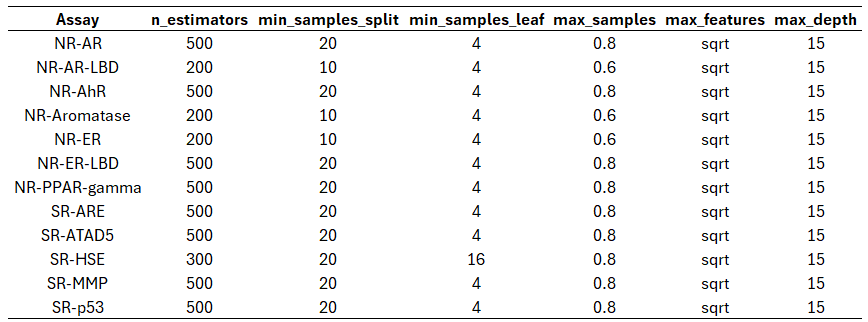

### Numerical Metrics

Default RF Baseline (0.5 default threshold):

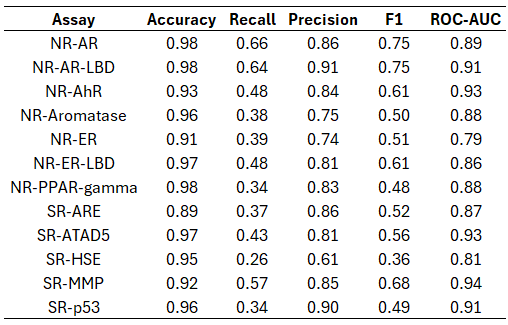

Tuned RF Model:

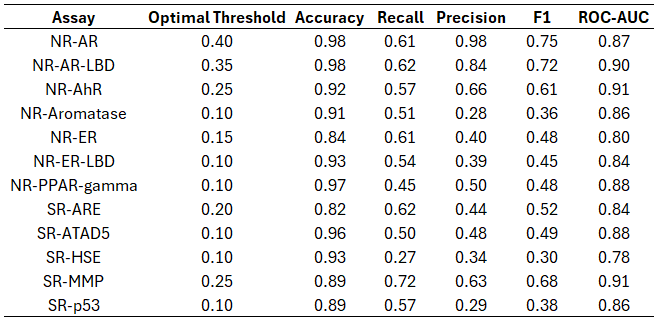

Neural Network:

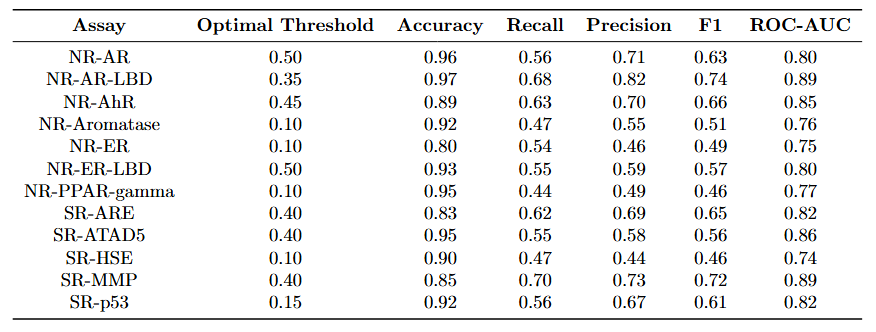

### ROC Curves

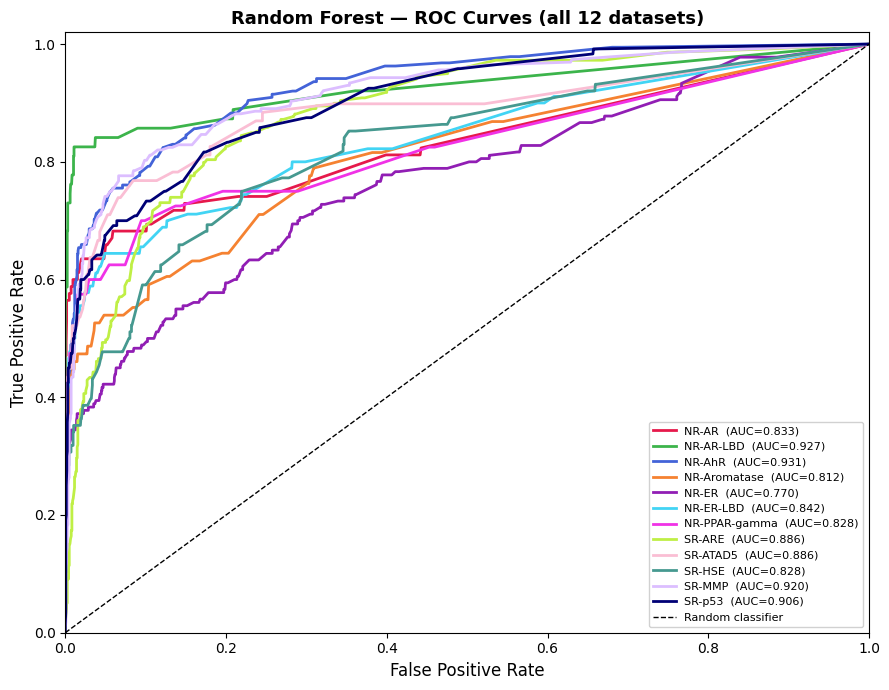


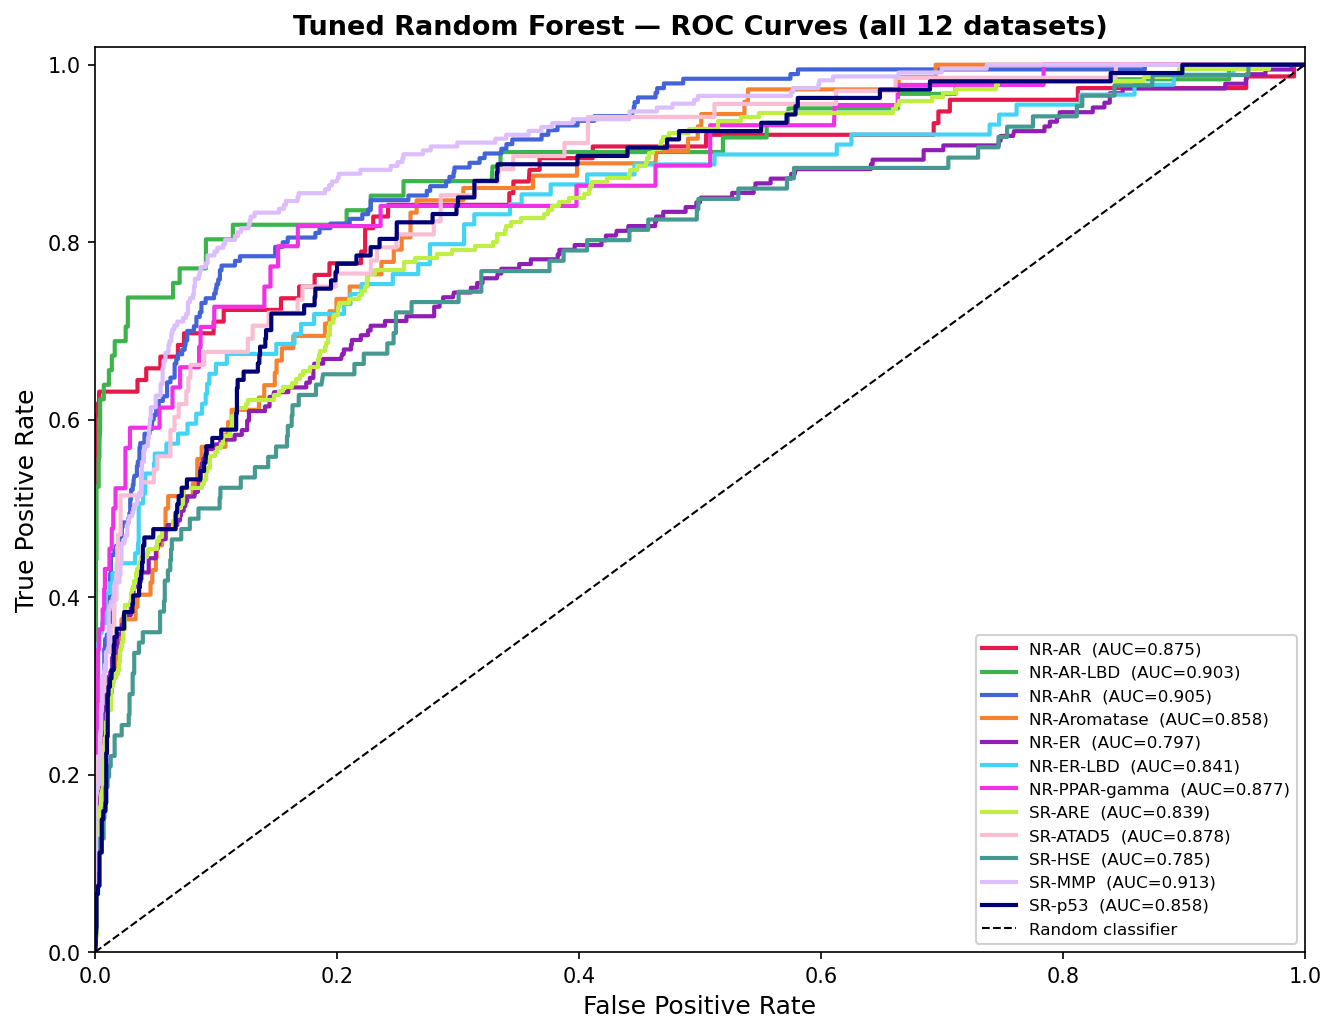



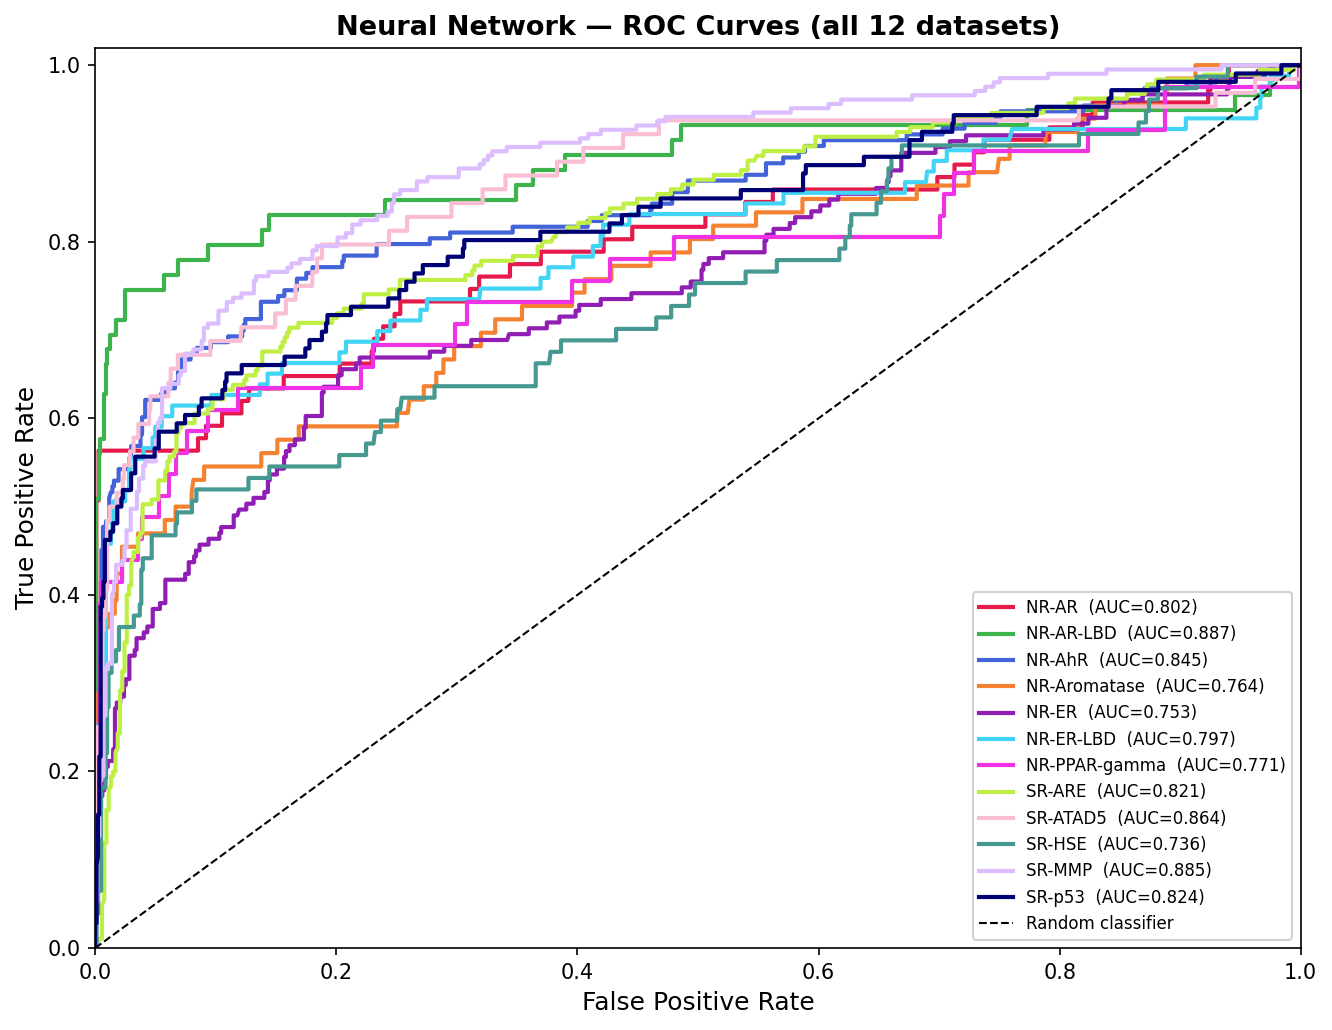

### Decision Threshold Comparison

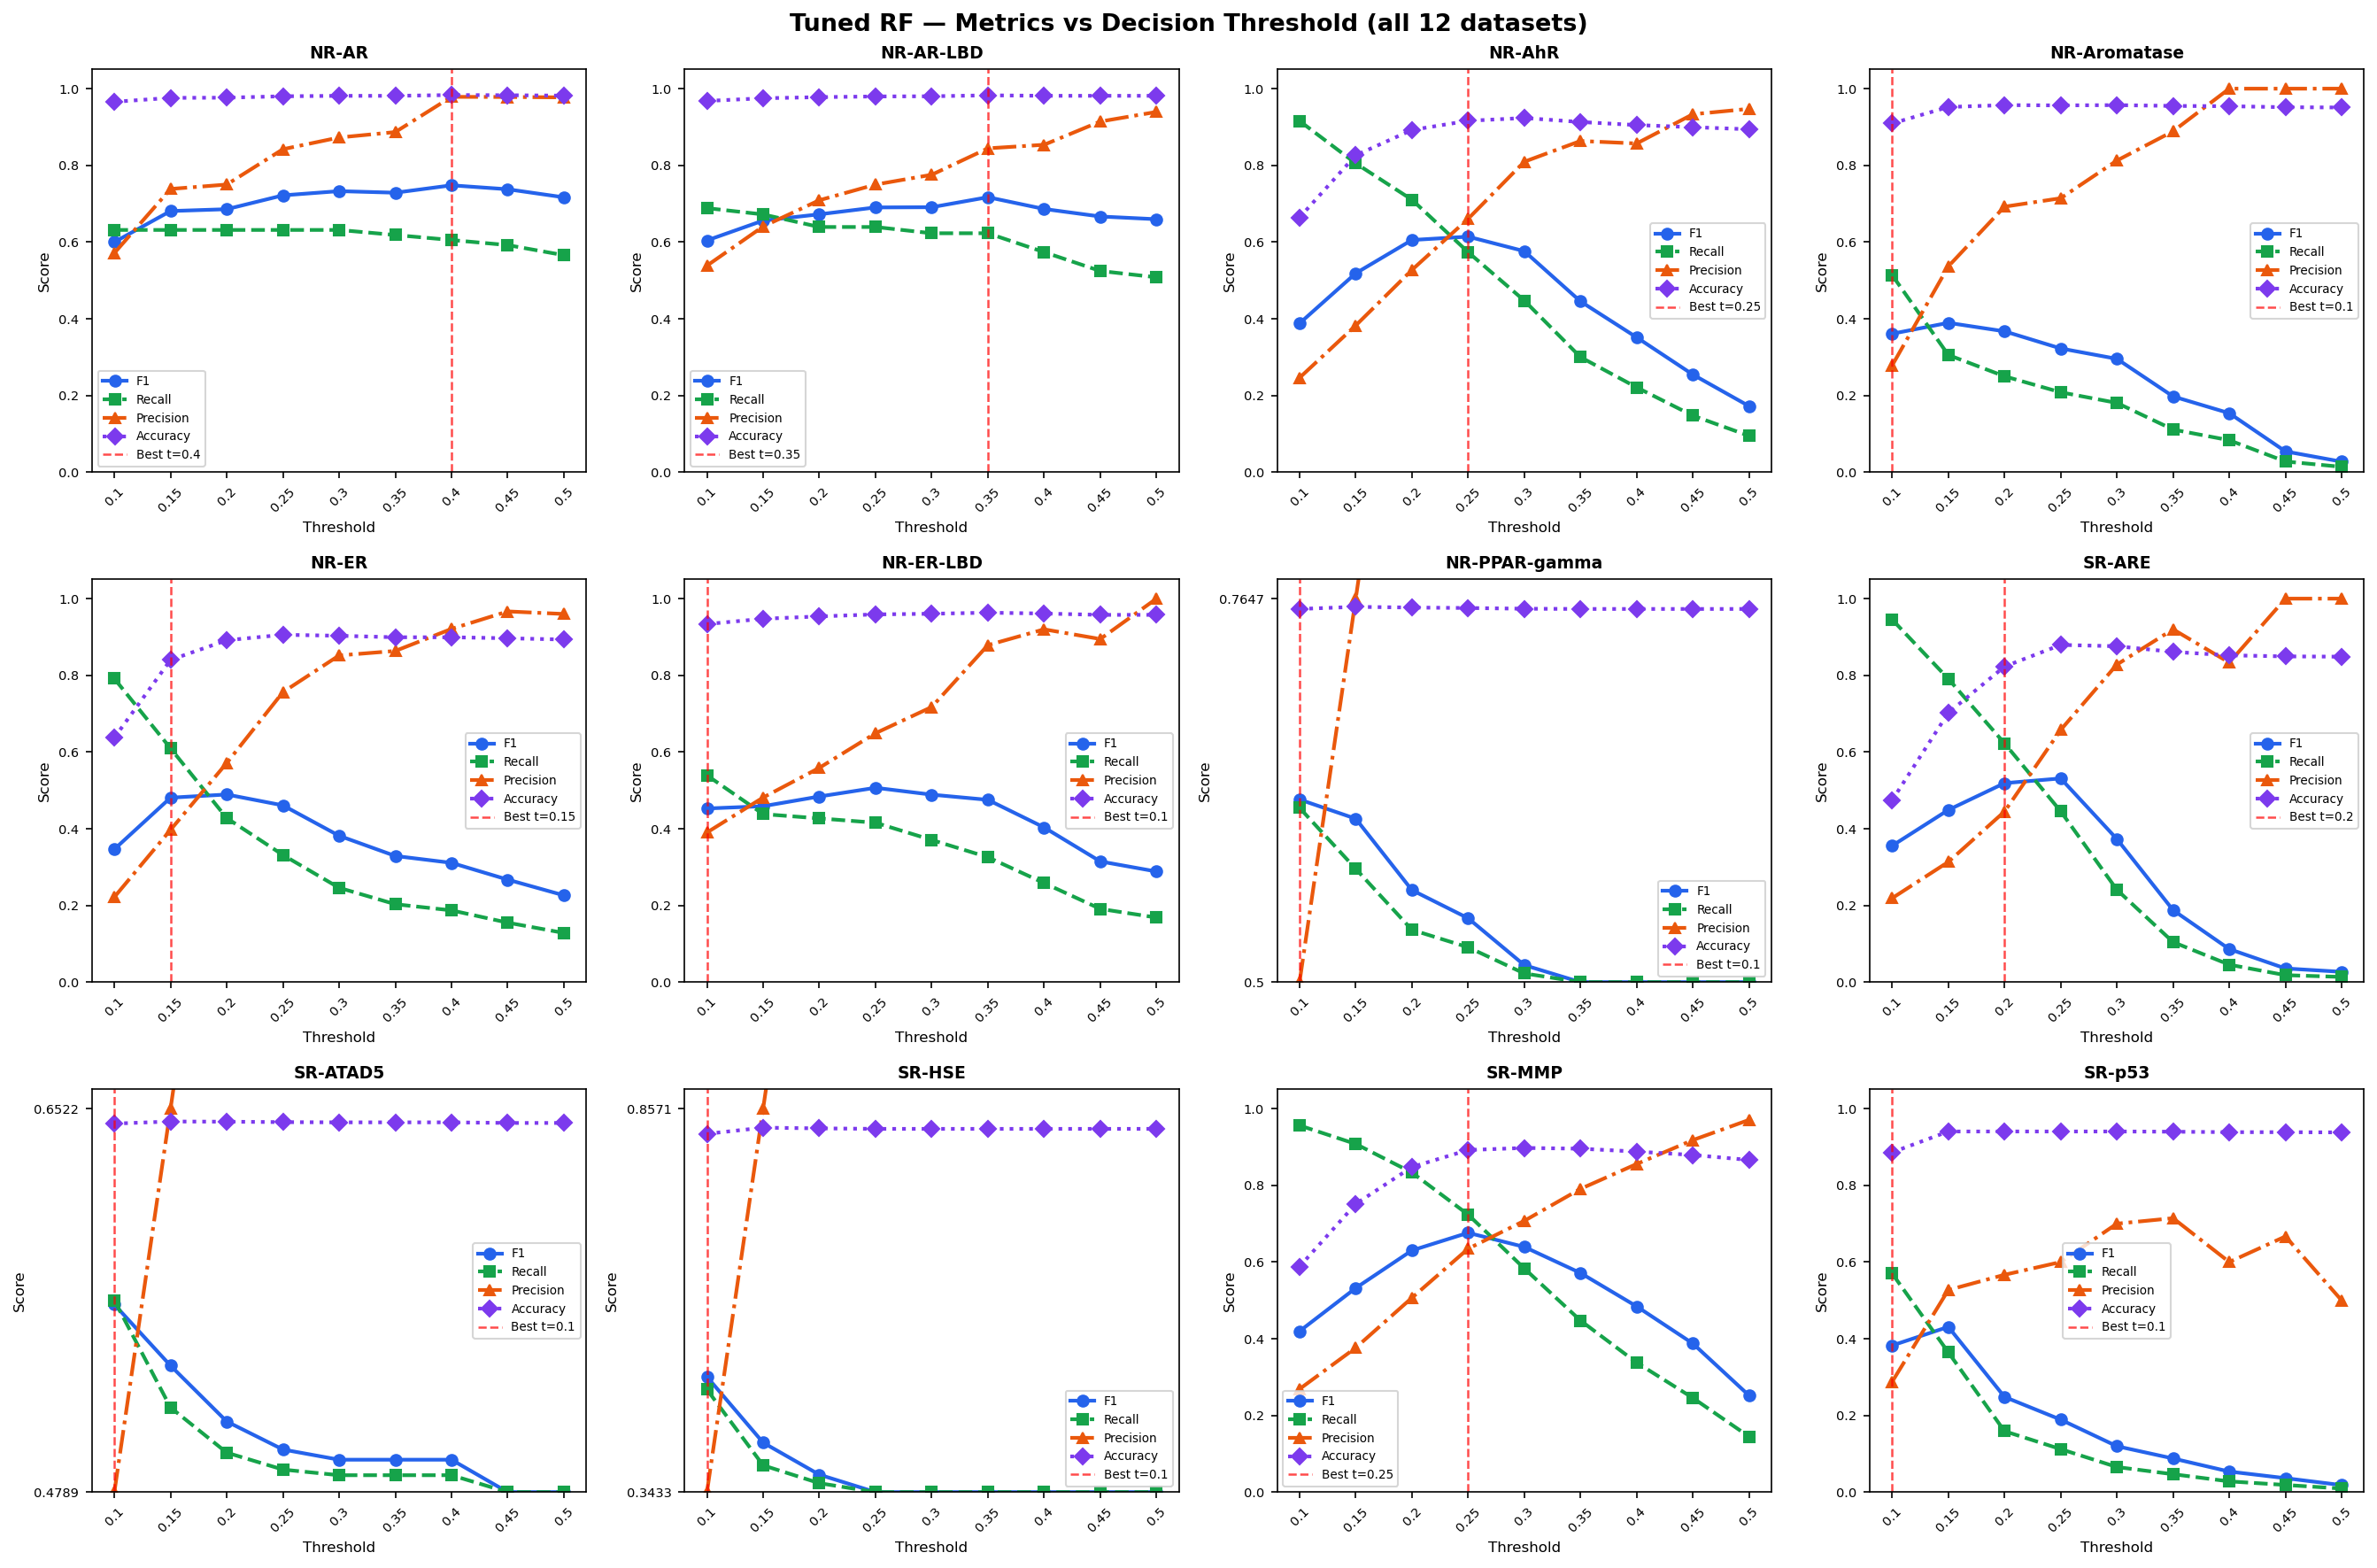


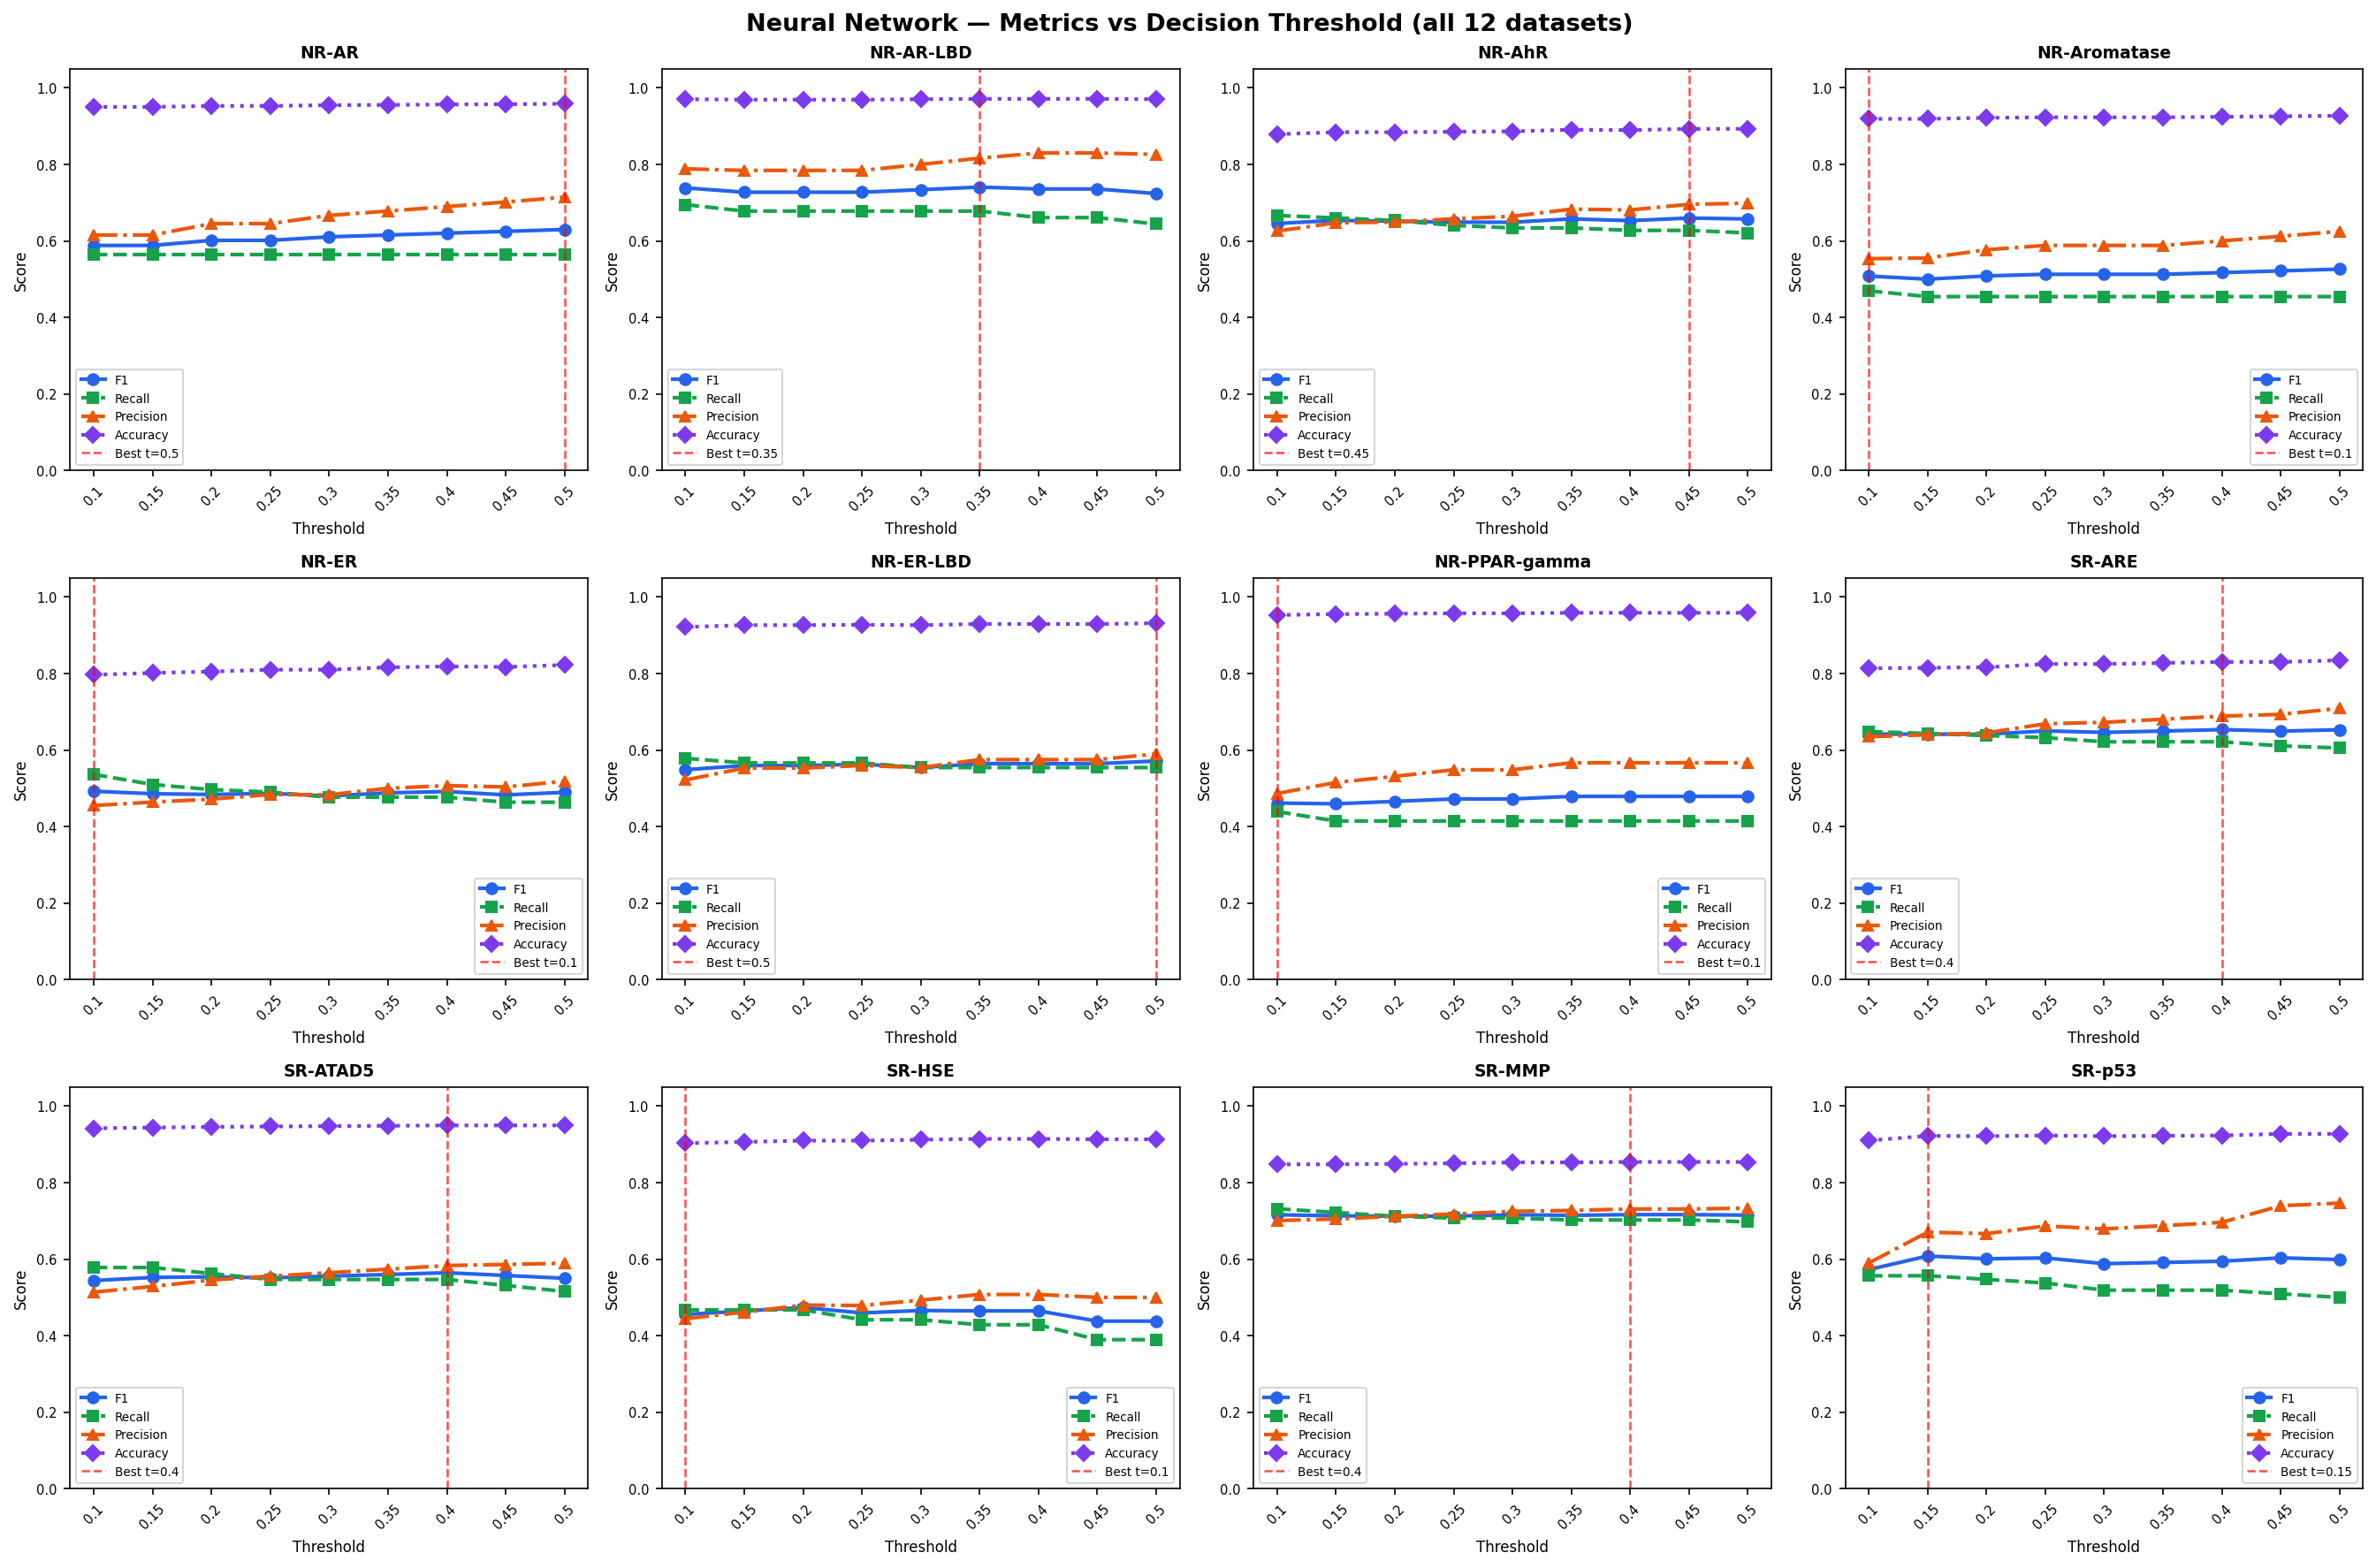

### SHAP Feature Analysis

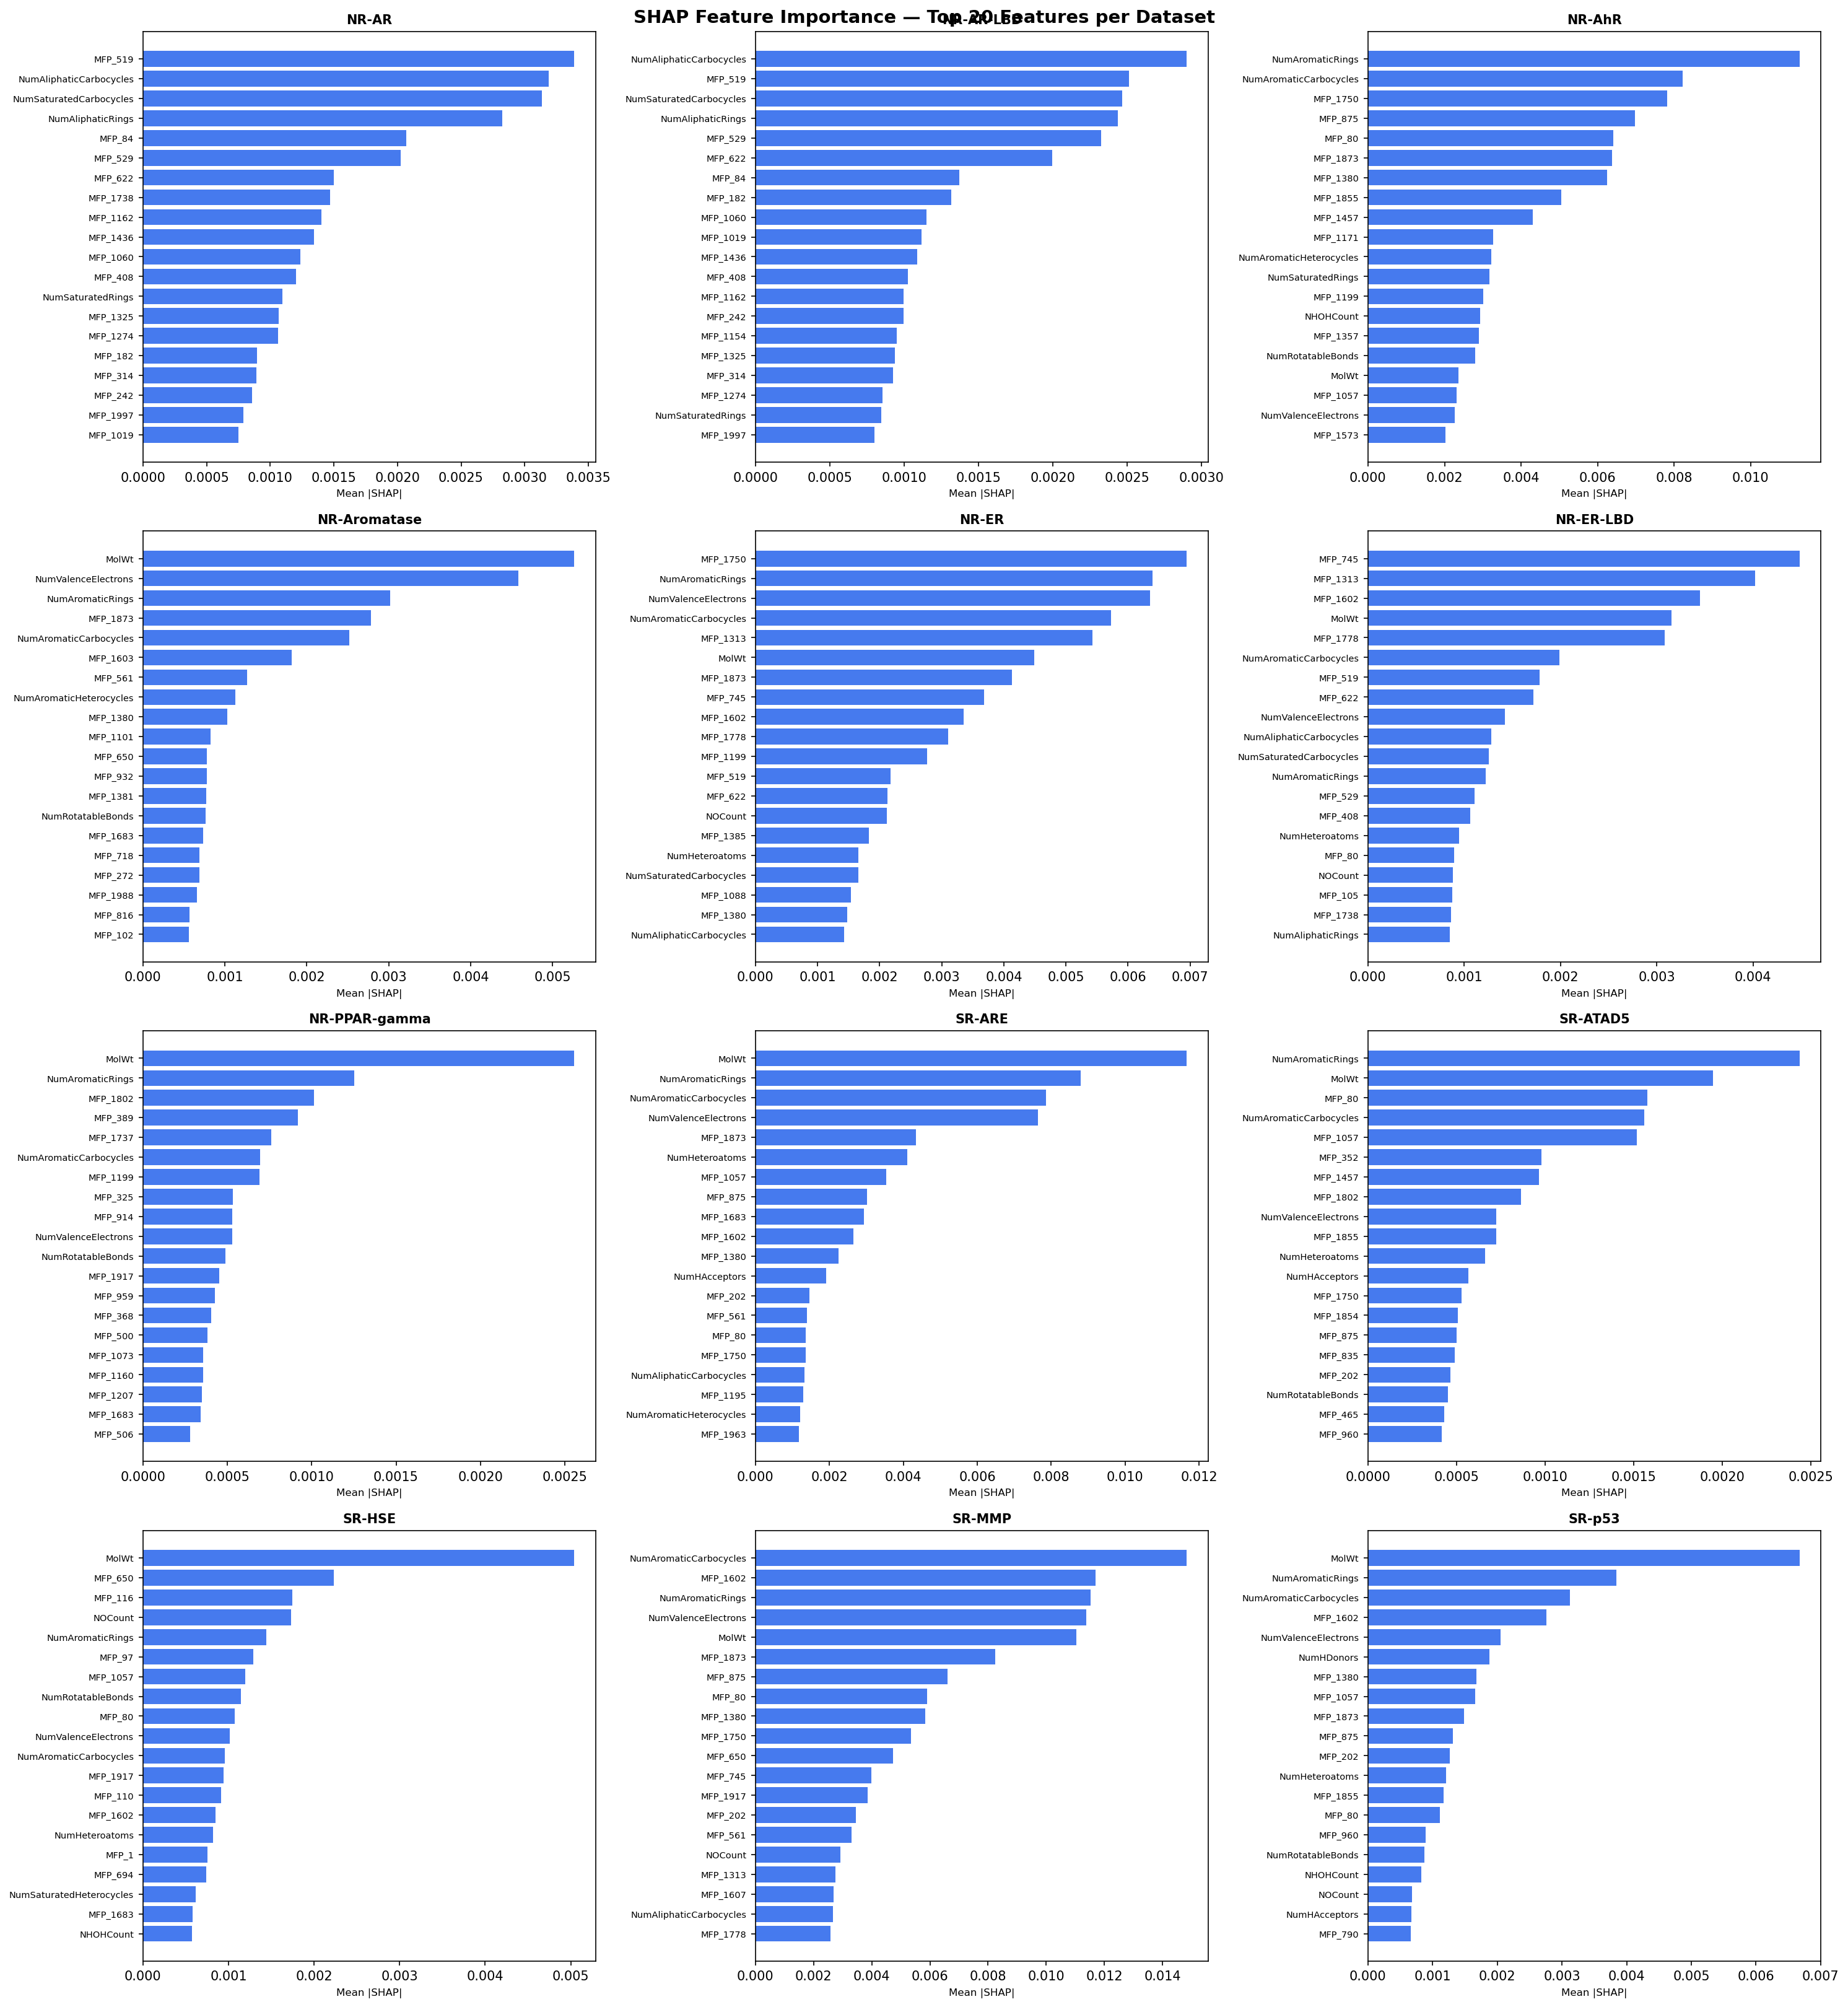

For Random Forest:

The key comparison columns are ROC-AUC and Recall at the selected threshold. The most surprising finding was the complete disconnect between CV F1/Recall and hold-out ROC-AUC for severely imbalanced assays — NR-PPAR-gamma showed CV F1=0.000 (model predicting all-negative in every fold at threshold 0.5) while simultaneously achieving ROC-AUC=0.877 on the hold-out set, meaning the model had strong discriminative ability that was completely invisible to threshold-dependent metrics. The SR-HSE assay was also surprising — even at threshold=0.10, recall only reached 0.267, suggesting the molecular features we computed may genuinely lack signal for that particular stress-response pathway.

We monitored train vs. validation AUC as the primary overfitting signal. Early models with max_depth=None showed gaps of 0.20–0.33, indicating clear overfitting — the train AUC would reach 0.98–0.99 while validation AUC sat at 0.60–0.75. To address this we progressively tightened the hyperparameter search space: removed unconstrained max_depth, raised min_samples_leaf floor from 1 to 4, added max_samples for row subsampling, and restricted max_features to sqrt/log2 only. The final results show all 12 datasets with train-val AUC gaps below 0.15 and — critically — hold-out test AUC within 0.04 of CV validation AUC, confirming the CV estimates generalize faithfully. Several datasets (NR-PPAR-gamma, SR-ATAD5, SR-HSE) show CV F1=0 which looks like underfitting but is actually the threshold collapse artifact described above; their ROC-AUC values (0.80–0.88) confirm the models are learning meaningful signal.

The ROC-AUC values (0.785–0.913) suggest the Morgan fingerprints plus hand-crafted descriptors capture genuine structure-activity relationships for most assays, but with meaningful variation across biological targets. Assays with cleaner structural signals (SR-MMP, NR-AhR, NR-AR-LBD) reached AUC above 0.90, while NR-ER and SR-HSE plateaued around 0.80, suggesting either weaker structural determinism or that relevant features are not well-represented in 2D fingerprints. The severe class imbalance (2–15% positive rates) reflects real-world toxicity data where most compounds are inactive, and it substantially shaped every modeling decision. On different data — e.g., external test sets from different chemical libraries or assay platforms — performance would likely degrade for the low-AUC assays first, since their learned patterns are less robust. The model would also be expected to underperform on chemical scaffolds underrepresented in Tox21 training data, a known limitation of Morgan fingerprint-based models (scaffold-dependent generalization).

Comparing with NN:

The neural network generally achieves lower ROC-AUC and F1 than the optimized random forest across all 12 assays. After threshold tuning, however, the recall gap narrows considerably. The most notable difference is SR-HSE: the RF fell back to max-recall selection because no threshold reached the 0.50 recall floor, resulting in a recall of only 0.27, while the NN achieved 0.47. This suggests the NN's architecture, despite its lower overall AUC, may be better suited to certain biologically complex assays where the RF's tree-splitting mechanism cannot capture the relevant feature interactions. The NN's underperformance on ROC-AUC likely reflects dataset size constraints. With 7,000–9,000 labeled samples per assay after removing missing values, the network lacks sufficient data to learn generalizable patterns from 2066-dimensional sparse input. DeepTox succeeded under similar conditions by augmenting training data from PubChem and ChEMBL and training all 12 assays simultaneously via multi-task learning — neither of which was available here.

SHAP Results:

The SHAP analysis reveals that global physicochemical descriptors — particularly molecular weight, aromaticity counts, and valence electrons — are consistently more influential than individual Morgan fingerprint bits, despite fingerprints comprising over 99% of the feature space by count. This suggests the toxicity signals in Tox21 are largely driven by broad molecular properties rather than the presence of specific structural fragments. The exception is NR-AhR, where aromatic ring count dominates with substantially higher importance than any other assay, which aligns with the known biology of the aryl hydrocarbon receptor pathway.

Conclusion:

Overall, the tuned random forest is the strongest model, winning ROC-AUC across all 12 assays. After threshold optimization, both models achieve comparable recall, with the NN holding a meaningful advantage only on SR-HSE. The underpeformance of the neural network is likely due to the dataset size, and the most important features were the hand-picked high-level descriptors.

# Discussion

## What you've learned

**What concepts from lecture/breakout were most relevant to your project? How so?**
**What aspects of your project did you find most surprising?**
**What lessons did you take from this project that you want to remember for the next ML project you work on? Do you think those lessons would transfer to other datasets and/or models? Why or why not?**
**What was the most helpful feedback you received during your presentation? Why?**
**If you had two more weeks to work on this project, what would you do next? Why?**

The lectures on Random Forest, Neural Networks, and their associated hyperparameters were the most relavent. Also, the homework 4 lab was very useful in introducing how to use pytorch for neural networks.

We were most surprised by the random forest performing better than the neural network based on ROC-AUC, since the overall challenge winner was a neural network. We believe this is due to limited amounts of training data (7-9k training points) within just the Tox21 dataset, which makes it hard for the NN to learn patters on the 2066 feature input.

We also were suprsised by how data exploration and pre-processing took significantly more time compared to what we predicted, as we had to hand-pick features, deal with missing values, and convert between molecular datatypes. We saw firsthand the importance of recall vs. precision when dealing with unbalanced outcomes, and how accuracy can be a flawed performance metric.

If we had more time to work on this project, we would investigate more into why DeepTox was so successful, and see if we could use their strategies to increase the performance of our neural network. One of these ways was using more training data from other sources beyond the Tox21 dataset, including large chemical databases such as PubChem.